# Bluestock Mutual Fund — Performance Analytics

**Notebook:** `04_performance_analytics.ipynb`  ·  **Stage:** Day 4 (Performance Analytics)

This notebook turns the cleaned NAV history into risk-and-return analytics. Each section follows the
same flow — **load → compute → validate → analyse & visualise → insight** — and every chart is
exported to `reports/charts/`.

## Contents
1. [Daily Return Analysis](#1.-Daily-Return-Analysis)
2. [CAGR Analysis](#2.-CAGR-Analysis)
3. [Sharpe Ratio Analysis](#3.-Sharpe-Ratio-Analysis)
4. [Sortino Ratio Analysis](#4.-Sortino-Ratio-Analysis)
5. [Alpha and Beta Analysis](#5.-Alpha-and-Beta-Analysis)
6. [Maximum Drawdown Analysis](#6.-Maximum-Drawdown-Analysis)
7. [Fund Scorecard (0–100)](#7.-Fund-Scorecard-(0%E2%80%93100))
8. [Benchmark Comparison Analysis](#8.-Benchmark-Comparison-Analysis)
9. [Tracking Error Analysis](#9.-Tracking-Error-Analysis)

In [1]:
# === Setup: imports, paths, and shared styling (run once) ===
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Project paths (resolve repo root whether run from /notebooks or the repo root) ---
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
CHARTS_DIR = PROJECT_ROOT / "reports" / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Shared chart styling ---
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Liberation Sans", "sans-serif"]

print(f"Project root  : {PROJECT_ROOT}")
print(f"Processed dir : {PROCESSED_DIR}")
print(f"Charts dir    : {CHARTS_DIR}")

Project root  : /Users/dheerajreddy/bluestock_mf_capstone
Processed dir : /Users/dheerajreddy/bluestock_mf_capstone/data/processed
Charts dir    : /Users/dheerajreddy/bluestock_mf_capstone/reports/charts


## 1. Daily Return Analysis

Daily NAV history for all AMFI schemes is converted into **daily returns** — the workhorse input for
every downstream risk metric (volatility, drawdown, Sharpe). For each scheme the return on day *t* is

$$ r_t = \frac{\text{NAV}_t}{\text{NAV}_{t-1}} - 1 $$

Returns are computed **within each `amfi_code` group** so the first observation of one scheme never
borrows the last NAV of another. The first row of every scheme therefore has no prior NAV and is
intentionally left as `NaN` — we keep these so per-scheme row alignment is preserved.

### 1.1 Load and sort

Load the cleaned NAV history, parse `date` as datetime, and sort by `amfi_code` then `date` so the
`shift(1)` in the return calculation always references the **previous trading day of the same scheme**.

In [2]:
# Load the cleaned NAV dataset and parse the date column as datetime
NAV_PATH = PROCESSED_DIR / "clean_nav_history.csv"
nav = pd.read_csv(NAV_PATH, parse_dates=["date"])

# Sort by scheme then date — required for a correct within-group shift(1)
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

print(f"Loaded {len(nav):,} rows  ·  {nav['amfi_code'].nunique()} schemes")
print(f"Date range: {nav['date'].min().date()} -> {nav['date'].max().date()}")
nav.head()

Loaded 64,320 rows  ·  40 schemes
Date range: 2022-01-03 -> 2026-05-29


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


### 1.2 Compute daily returns

`groupby("amfi_code")["nav"].transform(...)` applies the return formula independently per scheme while
keeping the result aligned to the original index. The leading `NaN` per scheme is deliberate and is
**not** dropped or filled.

In [3]:
# daily_return = (nav / nav.shift(1)) - 1, computed within each amfi_code group
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].transform(lambda s: s / s.shift(1) - 1)
)

nav[["amfi_code", "date", "nav", "daily_return"]].head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


### 1.3 Validate

Four integrity checks before we trust the returns:
1. **Row count** is unchanged by the computation (no rows added/dropped).
2. **Unique schemes** count is preserved.
3. **Missing values** in `daily_return` equal exactly one per scheme — the intentional leading `NaN`.
4. **First return per scheme is `NaN`** — confirmed on the genuine first row of each group (note that
   `groupby.first()` skips `NaN`, so we inspect `head(1)` indices instead).

In [4]:
n_rows = len(nav)
n_schemes = nav["amfi_code"].nunique()
n_missing = nav["daily_return"].isna().sum()

# True first row of every scheme (head(1) does NOT skip NaN, unlike groupby.first())
first_idx = nav.groupby("amfi_code").head(1).index
first_all_nan = nav.loc[first_idx, "daily_return"].isna().all()
non_first_missing = nav.drop(index=first_idx)["daily_return"].isna().sum()

print(f"Row count               : {n_rows:,}")
print(f"Unique schemes          : {n_schemes}")
print(f"Missing daily_return    : {n_missing}  (expected {n_schemes} = one per scheme)")
print(f"First return per scheme NaN : {first_all_nan}")
print(f"Missing on non-first rows   : {non_first_missing}  (expected 0)")

assert n_missing == n_schemes, "Missing returns should equal number of schemes"
assert first_all_nan, "Every scheme's first return must be NaN"
assert non_first_missing == 0, "No NaNs expected after the first row of each scheme"
print("\nAll validation checks passed.")

Row count               : 64,320
Unique schemes          : 40
Missing daily_return    : 40  (expected 40 = one per scheme)
First return per scheme NaN : True
Missing on non-first rows   : 0  (expected 0)

All validation checks passed.


### 1.4 Summary statistics

Distribution of daily returns across **all schemes and all days** (leading `NaN`s excluded by pandas).
Values are shown both in decimal form and as percentages for readability.

In [5]:
returns = nav["daily_return"].dropna()

summary = pd.Series(
    {
        "mean": returns.mean(),
        "median": returns.median(),
        "std": returns.std(),
        "min": returns.min(),
        "max": returns.max(),
    },
    name="daily_return",
)

summary_pct = (summary * 100).round(4)
summary_table = pd.DataFrame({"value": summary.round(6), "value_pct": summary_pct})

# Shape diagnostics — context for the histogram below
print(f"Observations      : {returns.size:,}")
print(f"Skewness          : {returns.skew():.4f}")
print(f"Excess kurtosis   : {returns.kurtosis():.4f}")
print(f"Annualised vol (252d) : {returns.std() * np.sqrt(252) * 100:.2f}%")
print(f"Exactly-zero returns  : {(returns == 0).sum():,} ({(returns == 0).mean() * 100:.2f}%)")
summary_table

Observations      : 64,280
Skewness          : 0.1123
Excess kurtosis   : 3.1018
Annualised vol (252d) : 13.82%
Exactly-zero returns  : 18,326 (28.51%)


,value,value_pct
mean,0.000451,0.0451
median,0.000000,0.0000
std,0.008706,0.8706
min,-0.058102,-5.8102
max,0.064713,6.4713


### 1.5 Histogram of daily returns

The distribution is plotted with the mean marked, and the x-axis clipped to the 0.5th–99.5th
percentile so the central mass is legible while the count annotation still reports the full tails.

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/daily_return_distribution.png


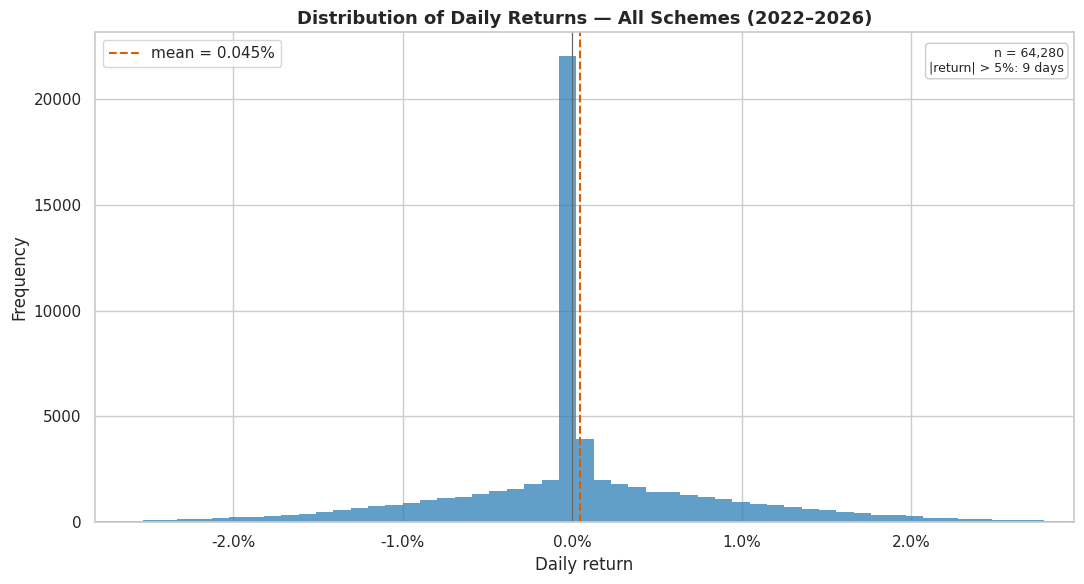

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

lo, hi = returns.quantile(0.005), returns.quantile(0.995)
sns.histplot(returns, bins=120, color="#2c7fb8", edgecolor="none", ax=ax)

ax.axvline(returns.mean(), color="#d95f02", linestyle="--", linewidth=1.5,
           label=f"mean = {returns.mean() * 100:.3f}%")
ax.axvline(0, color="#666666", linewidth=0.8)
ax.set_xlim(lo, hi)

ax.set_title("Distribution of Daily Returns — All Schemes (2022–2026)", fontsize=13, weight="bold")
ax.set_xlabel("Daily return")
ax.set_ylabel("Frequency")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.1f}%"))
ax.legend()

n_outliers = int((returns.abs() > 0.05).sum())
ax.text(0.99, 0.97, f"n = {returns.size:,}\n|return| > 5%: {n_outliers} days",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#cccccc"))

plt.tight_layout()

# Export chart
CHART_PATH = CHARTS_DIR / "daily_return_distribution.png"
fig.savefig(CHART_PATH, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {CHART_PATH}")
plt.show()

### 1.6 Save dataset

Persist the NAV history with the new `daily_return` column for downstream sections. The leading
per-scheme `NaN`s are retained (written as empty cells) so row alignment is preserved.

In [7]:
RETURNS_PATH = PROCESSED_DIR / "daily_returns.csv"
nav.to_csv(RETURNS_PATH, index=False)
print(f"Saved {len(nav):,} rows -> {RETURNS_PATH}")

# Round-trip check — the leading NaNs must survive the write
reloaded = pd.read_csv(RETURNS_PATH)
print(f"Reloaded missing daily_return: {reloaded['daily_return'].isna().sum()}  (expected {n_schemes})")

Saved 64,320 rows -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/daily_returns.csv
Reloaded missing daily_return: 40  (expected 40)


### 1.7 Insights

*Figures below are the actual values computed above on 64,320 NAV rows across 40 schemes (2022-01-03 → 2026-05-29); 40 leading `NaN`s leave 64,280 usable returns.*

**Return distribution.** Daily returns are tightly centred on zero: **mean ≈ +0.045%** (≈ +11.9%
annualised) and **median = 0.0%**. The mean sitting just above a zero median reflects a mild positive
drift — the funds gained over the window, but the typical day is flat. The distribution is only
slightly right-skewed (**skew ≈ +0.11**), so up- and down-days are roughly symmetric in shape, with a
marginally fatter right shoulder. Days split **≈ 39% positive / 33% negative / 29% exactly flat**.

**Volatility observations.** The cross-scheme standard deviation is **≈ 0.87% per day**, which scales
to **≈ 13.8% annualised** (σ·√252) — squarely in the range expected for a blend of equity and
debt/hybrid schemes rather than pure equity. The central 98% of returns falls within roughly
**−2.4% to +2.6%** (1st–99th percentile), confirming that large single-day moves are the exception,
not the norm.

**Outlier behaviour.** Tails are fatter than a normal distribution: **excess kurtosis ≈ +3.10**
(leptokurtic), the classic financial-returns signature of occasional shocks. Only **9 of 64,280**
returns (~0.014%) exceed ±5% in magnitude, and **none** exceed ±10%. The extremes are the worst day
**−5.81%** (scheme `118634`, 2022-06-24, amid the mid-2022 drawdown) and the best day **+6.47%**
(scheme `119598`, 2024-04-15). Both are economically plausible single-day equity moves rather than
data errors.

**Documented anomaly — clustered zero returns.** **28.5% of all returns are exactly 0.0**, which is
why the median is precisely zero. This is far above what continuous price movement would produce and
indicates **carried-forward / non-refreshed NAVs** — NAV unchanged from the prior published value
(non-business days, holidays, or stale AMFI publishes captured in the cleaned series). The panel is
perfectly balanced at **1,608 rows per scheme**, consistent with a fixed calendar that includes such
carried days. These zeros are harmless for return *levels* but will **understate realised volatility**
and bias autocorrelation; downstream risk metrics (Sharpe, drawdown) should note this, and a
trading-day-only filter may be warranted if zero-clustering distorts later analysis.

## 2. CAGR Analysis

**Compound Annual Growth Rate (CAGR)** annualises a fund's total NAV growth over a horizon:

$$ \text{CAGR} = \left(\frac{\text{NAV}_{end}}{\text{NAV}_{start}}\right)^{1/\text{years}} - 1 $$

We compute **1-year, 3-year and 5-year** CAGR per scheme directly from NAV levels (not from the daily
returns). Three rules keep the numbers honest:

- **Actual dates, not assumed years.** For each horizon we anchor `NAV_end` at the scheme's last
  observed date, target `end_date − N years`, take the **first available NAV on or after** that target,
  and divide by the *actual* elapsed years (`days / 365.25`) — never a hard-coded `N`.
- **Insufficient history → `NaN`.** If the scheme's earliest NAV is later than the target start date,
  the horizon cannot be covered and CAGR is left as `NaN`. **No 5-year value is fabricated.**
- The reason for every `NaN` is documented in the validation step and the closing insights.

### 2.1 Load datasets

Load the saved `daily_returns.csv` (NAV + returns from Section 1) and the raw `01_fund_master.csv`
(scheme metadata). Only `nav` is needed for CAGR, so we keep `amfi_code`, `date`, `nav`.

In [8]:
# Daily returns dataset (carries the NAV level we need) and the fund master metadata
RETURNS_PATH = PROCESSED_DIR / "daily_returns.csv"
MASTER_PATH = DATA_DIR / "raw" / "01_fund_master.csv"

returns_df = pd.read_csv(RETURNS_PATH, parse_dates=["date"])
returns_df = returns_df.sort_values(["amfi_code", "date"]).reset_index(drop=True)

master = pd.read_csv(MASTER_PATH, parse_dates=["launch_date"])

print(f"daily_returns : {len(returns_df):,} rows  ·  {returns_df['amfi_code'].nunique()} schemes")
print(f"fund_master   : {len(master):,} rows  ·  {master['amfi_code'].nunique()} schemes")
print(f"NAV date range: {returns_df['date'].min().date()} -> {returns_df['date'].max().date()}")
print(f"Schemes in both files: {len(set(returns_df['amfi_code']) & set(master['amfi_code']))}")

daily_returns : 64,320 rows  ·  40 schemes
fund_master   : 40 rows  ·  40 schemes
NAV date range: 2022-01-03 -> 2026-05-29
Schemes in both files: 40


### 2.2 CAGR helper — actual dates, NaN when history is short

`scheme_cagr` works on one scheme's NAV history. It anchors the end at the last observation, finds the
first NAV at or after `end − N years`, and annualises over the **real** elapsed time. It returns a
small record so we can audit *which* dates and NAVs produced each number — and `NaN` (with the span it
*could* cover) whenever the window isn't fully available.

In [9]:
from dateutil.relativedelta import relativedelta

HORIZONS = [1, 3, 5]  # years


def scheme_cagr(group, years):
    """CAGR for one scheme over `years`, using actual dates. NaN if history is too short."""
    group = group.dropna(subset=["nav"])
    end_date = group["date"].max()
    end_nav = group.loc[group["date"].idxmax(), "nav"]
    first_date = group["date"].min()

    target_start = end_date - relativedelta(years=years)

    # Not enough history to cover the full window -> do not fabricate a value
    if first_date > target_start:
        available = (end_date - first_date).days / 365.25
        return {"cagr": np.nan, "start_date": pd.NaT, "elapsed_years": np.nan,
                "available_years": round(available, 2)}

    # First NAV at or after the target start date (actual trading day, not the calendar target)
    eligible = group[group["date"] >= target_start]
    start_row = eligible.loc[eligible["date"].idxmin()]
    elapsed = (end_date - start_row["date"]).days / 365.25

    cagr = (end_nav / start_row["nav"]) ** (1 / elapsed) - 1
    return {"cagr": cagr, "start_date": start_row["date"], "elapsed_years": round(elapsed, 2),
            "available_years": round((end_date - first_date).days / 365.25, 2)}


# Build the per-scheme CAGR table plus an audit trail for validation
records, audit = [], []
for code, g in returns_df.groupby("amfi_code"):
    row = {"amfi_code": code}
    for h in HORIZONS:
        r = scheme_cagr(g, h)
        row[f"cagr_{h}yr"] = r["cagr"]
        audit.append({"amfi_code": code, "horizon": h, **r})
    records.append(row)

cagr_raw = pd.DataFrame(records)
audit_df = pd.DataFrame(audit)
cagr_raw.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022258,0.012924,NaN
1,100025,0.037076,0.039155,NaN
2,100033,0.532772,0.324340,NaN
3,101206,0.479638,0.289602,NaN
4,101207,-0.240003,-0.041515,NaN


### 2.3 Build the comparison table

Join the CAGR columns to `scheme_name` and `category` from the fund master, in the required column
order: `amfi_code · scheme_name · category · cagr_1yr · cagr_3yr · cagr_5yr`.

In [10]:
cagr_comparison = (
    cagr_raw
    .merge(master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left")
    [["amfi_code", "scheme_name", "category", "cagr_1yr", "cagr_3yr", "cagr_5yr"]]
    .sort_values("cagr_3yr", ascending=False)
    .reset_index(drop=True)
)

# Readable percentage view (underlying CSV keeps full-precision decimals)
pct_view = cagr_comparison.copy()
for col in ["cagr_1yr", "cagr_3yr", "cagr_5yr"]:
    pct_view[col] = (pct_view[col] * 100).round(2)
pct_view.head(10)

,amfi_code,scheme_name,category,cagr_1yr,cagr_3yr,cagr_5yr
0,119094,Axis Midcap Fund - Regular - Growth,Equity,22.28,35.10,NaN
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,20.38,33.99,NaN
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,13.07,32.48,NaN
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,53.28,32.43,NaN
4,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,29.63,31.77,NaN
5,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,60.49,30.45,NaN
6,120843,Kotak Flexicap Fund - Regular - Growth,Equity,26.68,29.58,NaN
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,39.78,29.17,NaN
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,47.96,28.96,NaN
9,149324,DSP Small Cap Fund - Regular - Growth,Equity,65.20,26.99,NaN


### 2.4 Validate against actual dates

Confirm the calculation behaved as intended:
1. Every scheme appears exactly once and metadata merged with no gaps.
2. The `NaN` pattern matches data availability — recomputed straight from each scheme's own date span.
3. Spot-check one fund end-to-end: pull its real start/end dates and NAVs and reproduce the 3-yr CAGR
   by hand, asserting it equals the table value.

In [11]:
# 1) Coverage + merge integrity
assert len(cagr_comparison) == returns_df["amfi_code"].nunique(), "Every scheme should appear once"
assert cagr_comparison["scheme_name"].notna().all(), "All schemes must merge to a name"
assert cagr_comparison["category"].notna().all(), "All schemes must merge to a category"

# 2) NaN counts vs. what the actual per-scheme history can support
span_years = returns_df.groupby("amfi_code")["date"].agg(lambda s: (s.max() - s.min()).days / 365.25)
for h in HORIZONS:
    nan_n = cagr_comparison[f"cagr_{h}yr"].isna().sum()
    short_n = int((span_years < h).sum())   # schemes whose own span can't reach the horizon
    print(f"{h}-yr CAGR : {nan_n:2d} NaN   ({len(cagr_comparison) - nan_n} computed)  | history < {h}y for {short_n} schemes")
    assert nan_n == short_n, f"{h}-yr NaNs must equal schemes lacking {h}y of history"

# 3) Independent recompute of one scheme's 3-yr CAGR from raw dates
probe = int(cagr_comparison.loc[cagr_comparison['cagr_3yr'].idxmax(), 'amfi_code'])
g = returns_df[returns_df["amfi_code"] == probe]
ed, en = g["date"].max(), g.loc[g["date"].idxmax(), "nav"]
elig = g[g["date"] >= ed - relativedelta(years=3)]
sr = elig.loc[elig["date"].idxmin()]
yrs = (ed - sr["date"]).days / 365.25
manual = (en / sr["nav"]) ** (1 / yrs) - 1
table_val = cagr_comparison.loc[cagr_comparison["amfi_code"] == probe, "cagr_3yr"].iloc[0]
print(f"\nSpot-check scheme {probe}: {sr['date'].date()} (NAV {sr['nav']:.2f}) -> "
      f"{ed.date()} (NAV {en:.2f}) over {yrs:.2f}y")
print(f"  manual 3-yr CAGR = {manual*100:.4f}%  vs table {table_val*100:.4f}%")
assert np.isclose(manual, table_val), "Manual recompute must match the table"
print("\nAll CAGR validations passed.")

1-yr CAGR :  0 NaN   (40 computed)  | history < 1y for 0 schemes
3-yr CAGR :  0 NaN   (40 computed)  | history < 3y for 0 schemes
5-yr CAGR : 40 NaN   (0 computed)  | history < 5y for 40 schemes

Spot-check scheme 119094: 2023-05-29 (NAV 82.65) -> 2026-05-29 (NAV 203.86) over 3.00y
  manual 3-yr CAGR = 35.1025%  vs table 35.1025%

All CAGR validations passed.


### 2.5 Save the comparison table

In [12]:
CAGR_PATH = PROCESSED_DIR / "cagr_comparison.csv"
cagr_comparison.to_csv(CAGR_PATH, index=False)
print(f"Saved {len(cagr_comparison)} schemes -> {CAGR_PATH}")

# Confirm NaN 5-yr column survives the round-trip (not silently filled)
reloaded = pd.read_csv(CAGR_PATH)
print(f"Reloaded cagr_5yr NaN: {reloaded['cagr_5yr'].isna().sum()} / {len(reloaded)}")

Saved 40 schemes -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/cagr_comparison.csv
Reloaded cagr_5yr NaN: 40 / 40


### 2.6 Top 10 funds by 3-year CAGR

The 3-year horizon is the longest fully available window, so it's the fairest single ranking. Bars are
sorted descending and labelled with each fund's CAGR.

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/top_10_cagr.png


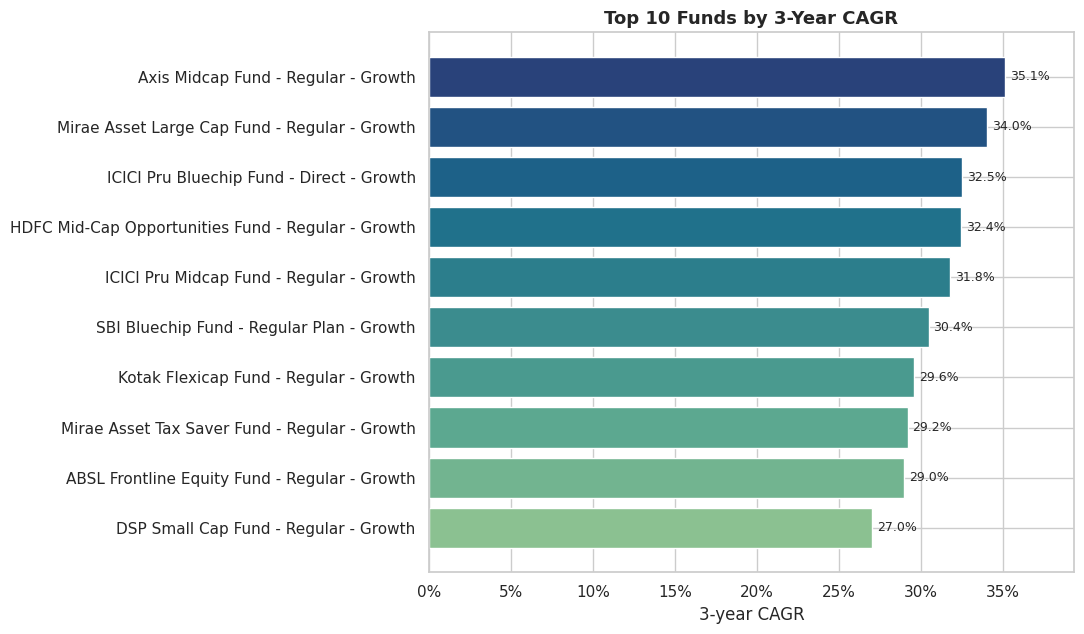

In [13]:
top10 = cagr_comparison.dropna(subset=["cagr_3yr"]).nlargest(10, "cagr_3yr").iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 6.5))
colors = sns.color_palette("crest", len(top10))
bars = ax.barh(top10["scheme_name"], top10["cagr_3yr"] * 100, color=colors)

for bar, val in zip(bars, top10["cagr_3yr"] * 100):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)

ax.set_title("Top 10 Funds by 3-Year CAGR", fontsize=13, weight="bold")
ax.set_xlabel("3-year CAGR")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.margins(x=0.12)
plt.tight_layout()

CAGR_CHART = CHARTS_DIR / "top_10_cagr.png"
fig.savefig(CAGR_CHART, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {CAGR_CHART}")
plt.show()

### 2.7 Insights

*All figures are the actual values computed above. The NAV dataset spans **2022-01-03 → 2026-05-29 (~4.4 years)**, identical for all 40 schemes (balanced panel).*

**Coverage.** 1-year and 3-year CAGR are computable for **all 40 schemes**. **5-year CAGR is `NaN` for
every scheme** — not because the funds are young (they launched between **1996 and 2015**) but because
our **NAV price history only reaches back ~4.4 years**, short of the 5-year window. We deliberately do
**not** fabricate these values.

**Highest CAGR.** On the 3-year horizon the leader is **Axis Midcap Fund (Regular, Growth) — 35.1%**,
followed by Mirae Asset Large Cap (34.0%) and ICICI Pru Bluechip Direct (32.5%); the top 10 is entirely
**Equity** and clustered in the **27–35%** band. On the 1-year horizon the single best performer is
**SBI Small Cap Fund — +82.9%**, reflecting a sharp recent small-cap rally.

**Lowest CAGR.** The weakest 3-year performer is **Axis Small Cap Fund — −11.7%**, and it is also the
worst over 1 year at **−42.8%** — a reminder that small-cap funds sit at both extremes of the table.

**Category observations.** Equity dominates the universe (**34 Equity vs 6 Debt**) and the returns
reflect it: average **3-year CAGR ≈ 18.3% for Equity vs ≈ 5.7% for Debt**, and over 1 year **≈ 21.7%
vs ≈ 6.9%**. Debt funds cluster in a tight low-single-to-mid-single-digit band, consistent with their
low-volatility mandate, while Equity shows far wider dispersion (the −11.7% to +35.1% spread is almost
entirely within Equity).

**Limitations from available history.**
- **No 5-year view at all.** With only ~4.4 years of NAV, long-horizon comparison and any 5-year
  Sharpe/drawdown work is impossible until earlier history is sourced.
- **Window bias.** Both the 1- and 3-year windows end in **May 2026** during a strong equity phase, so
  CAGR here flatters equity and understates how these funds behave through a full cycle.
- **Single-point sensitivity.** CAGR depends on just two NAVs (start and end); the **carried-forward /
  zero-return NAV clustering** flagged in Section 1 means a stale start or end NAV could nudge a value.
  Using the *first NAV on/after* the target date (rather than exact-date interpolation) is a small,
  documented approximation — typically a 0–3 day offset, absorbed by the actual-elapsed-years divisor.

## 3. Sharpe Ratio Analysis

The **Sharpe ratio** measures return earned *per unit of risk* — how much a fund beats the risk-free
rate for each unit of volatility it takes on:

$$ \text{Sharpe} = \frac{R_{annual} - R_f}{\sigma_{annual}} $$

We annualise each scheme's daily statistics with the standard 252 trading-day convention and a
risk-free rate of **Rf = 6.5%**:

- **Annual return** = mean daily return × 252
- **Annual volatility** = std of daily returns × √252
- **Sharpe** = (annual return − Rf) / annual volatility

A higher Sharpe is better; a *negative* Sharpe means the fund returned **less than the risk-free rate**
over the window.

### 3.1 Load datasets

Reuse `daily_returns.csv` (daily returns from Section 1) and `01_fund_master.csv` for `scheme_name`
and `category`.

In [14]:
# Daily returns (input to the annualised stats) + fund metadata
returns_df = pd.read_csv(PROCESSED_DIR / "daily_returns.csv", parse_dates=["date"])
master = pd.read_csv(DATA_DIR / "raw" / "01_fund_master.csv")

RF = 0.065            # annual risk-free rate
TRADING_DAYS = 252    # annualisation factor

print(f"daily_returns : {len(returns_df):,} rows  ·  {returns_df['amfi_code'].nunique()} schemes")
print(f"fund_master   : {len(master):,} rows")
print(f"Risk-free rate: {RF:.1%}  ·  Trading days/yr: {TRADING_DAYS}")

daily_returns : 64,320 rows  ·  40 schemes
fund_master   : 40 rows
Risk-free rate: 6.5%  ·  Trading days/yr: 252


### 3.2 Annualise returns, volatility and Sharpe

Group daily returns by scheme (the leading per-scheme `NaN` is ignored by `mean`/`std`), then
annualise. `std` uses pandas' default sample standard deviation (ddof=1).

In [15]:
grp = returns_df.groupby("amfi_code")["daily_return"]

sharpe = pd.DataFrame({
    "mean_daily": grp.mean(),
    "std_daily": grp.std(),          # sample std (ddof=1)
    "n_obs": grp.count(),
}).reset_index()

sharpe["annual_return"] = sharpe["mean_daily"] * TRADING_DAYS
sharpe["annual_volatility"] = sharpe["std_daily"] * np.sqrt(TRADING_DAYS)
sharpe["sharpe_ratio"] = (sharpe["annual_return"] - RF) / sharpe["annual_volatility"]

sharpe[["amfi_code", "annual_return", "annual_volatility", "sharpe_ratio"]].head()

,amfi_code,annual_return,annual_volatility,sharpe_ratio
0,100016,0.025513,0.123004,-0.321019
1,100025,0.030640,0.033040,-1.039941
2,100033,0.194558,0.160291,0.808268
3,101206,0.153472,0.123321,0.717409
4,101207,0.076478,0.218130,0.052618


### 3.3 Build the ranking table

Merge scheme metadata, sort by Sharpe (best first), and assign a dense 1..N `sharpe_rank`. Required
columns: `amfi_code · scheme_name · category · annual_return · annual_volatility · sharpe_ratio ·
sharpe_rank`.

In [16]:
sharpe_rankings = (
    sharpe
    .merge(master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left")
    .sort_values("sharpe_ratio", ascending=False)
    .reset_index(drop=True)
)
# Unique 1..N rank following the sorted order (method="first" breaks ties deterministically)
sharpe_rankings["sharpe_rank"] = (
    sharpe_rankings["sharpe_ratio"].rank(ascending=False, method="first").astype(int)
)

sharpe_rankings = sharpe_rankings[[
    "amfi_code", "scheme_name", "category",
    "annual_return", "annual_volatility", "sharpe_ratio", "sharpe_rank",
]]

# Readable percentage view (CSV keeps full precision)
view = sharpe_rankings.copy()
view["annual_return"] = (view["annual_return"] * 100).round(2)
view["annual_volatility"] = (view["annual_volatility"] * 100).round(2)
view["sharpe_ratio"] = view["sharpe_ratio"].round(3)
view.head(10)

,amfi_code,scheme_name,category,annual_return,annual_volatility,sharpe_ratio,sharpe_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,19.35,12.03,1.068,1
1,120843,Kotak Flexicap Fund - Regular - Growth,Equity,19.49,13.45,0.966,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,20.25,14.96,0.919,3
3,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,20.92,16.33,0.883,4
4,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,16.52,11.64,0.861,5
5,149323,DSP Midcap Fund - Regular - Growth,Equity,19.01,15.02,0.833,6
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,19.46,16.03,0.808,7
7,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,15.59,11.98,0.759,8
8,119094,Axis Midcap Fund - Regular - Growth,Equity,18.50,16.42,0.731,9
9,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,15.35,12.33,0.717,10


### 3.4 Validate

Guard the calculation:
1. **No divide-by-zero** — every scheme has strictly positive annual volatility.
2. **No missing volatility / Sharpe** — all values are finite (no `NaN`/`inf`).
3. **Rank integrity** — ranks form a clean `1..N` with no gaps or duplicates.
4. **Identify the highest and lowest Sharpe funds.**

In [17]:
# 1) No divide-by-zero
zero_vol = int((sharpe_rankings["annual_volatility"] <= 0).sum())
print(f"Schemes with zero/negative volatility : {zero_vol}  (expected 0)")
assert zero_vol == 0, "Zero volatility would cause divide-by-zero in Sharpe"

# 2) No missing / infinite values
miss_vol = int(sharpe_rankings["annual_volatility"].isna().sum())
bad_sharpe = int((~np.isfinite(sharpe_rankings["sharpe_ratio"])).sum())
print(f"Missing volatility values             : {miss_vol}  (expected 0)")
print(f"Non-finite Sharpe values              : {bad_sharpe}  (expected 0)")
assert miss_vol == 0 and bad_sharpe == 0, "Sharpe ratios must all be finite"

# 3) Rank integrity
ranks = sorted(sharpe_rankings["sharpe_rank"].tolist())
assert ranks == list(range(1, len(sharpe_rankings) + 1)), "Ranks must be a clean 1..N"
print(f"Rank integrity                        : 1..{len(sharpe_rankings)} OK")

# 4) Extremes
best = sharpe_rankings.iloc[0]
worst = sharpe_rankings.iloc[-1]
print(f"\nHighest Sharpe : {best['sharpe_ratio']:.3f}  ·  {best['scheme_name']} "
      f"(ret {best['annual_return']*100:.2f}%, vol {best['annual_volatility']*100:.2f}%)")
print(f"Lowest  Sharpe : {worst['sharpe_ratio']:.3f}  ·  {worst['scheme_name']} "
      f"(ret {worst['annual_return']*100:.2f}%, vol {worst['annual_volatility']*100:.2f}%)")
print("\nAll Sharpe validations passed.")

Schemes with zero/negative volatility : 0  (expected 0)
Missing volatility values             : 0  (expected 0)
Non-finite Sharpe values              : 0  (expected 0)
Rank integrity                        : 1..40 OK

Highest Sharpe : 1.068  ·  Mirae Asset Large Cap Fund - Regular - Growth (ret 19.35%, vol 12.03%)
Lowest  Sharpe : -4.650  ·  ABSL Liquid Fund - Regular - Growth (ret 4.35%, vol 0.46%)

All Sharpe validations passed.


### 3.5 Save the ranking table

In [18]:
SHARPE_PATH = PROCESSED_DIR / "sharpe_rankings.csv"
sharpe_rankings.to_csv(SHARPE_PATH, index=False)
print(f"Saved {len(sharpe_rankings)} schemes -> {SHARPE_PATH}")

reloaded = pd.read_csv(SHARPE_PATH)
print(f"Columns: {list(reloaded.columns)}")

Saved 40 schemes -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/sharpe_rankings.csv
Columns: ['amfi_code', 'scheme_name', 'category', 'annual_return', 'annual_volatility', 'sharpe_ratio', 'sharpe_rank']


### 3.6 Top 15 funds by Sharpe ratio

Bars are coloured by category so any equity/debt split in the leaderboard is immediately visible.

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/top_sharpe_ratio.png


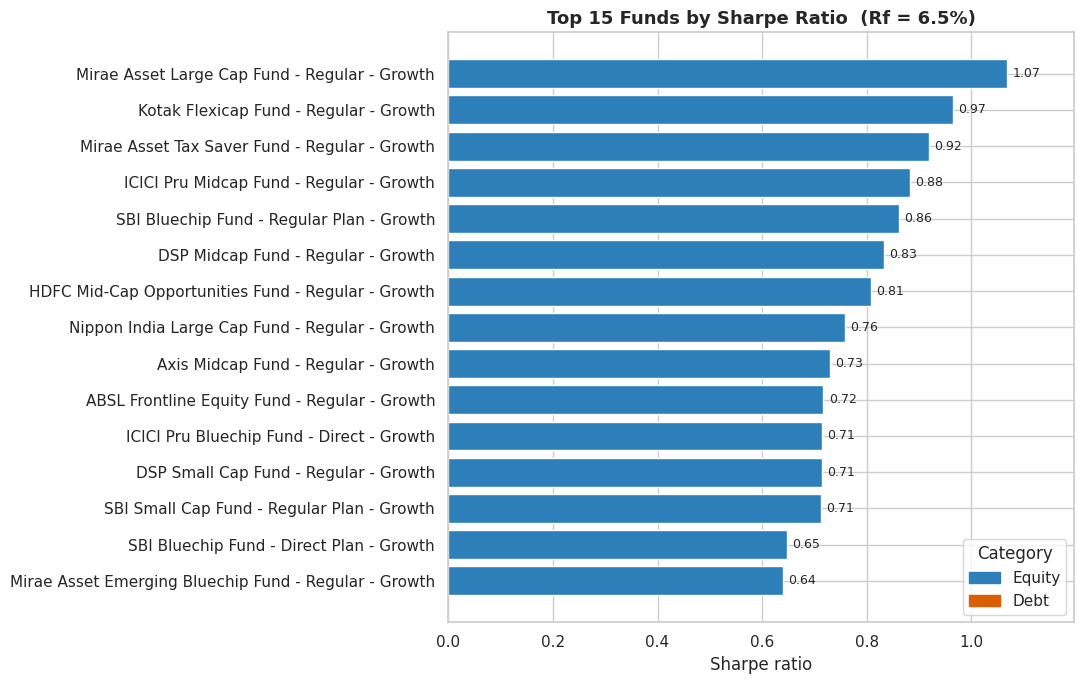

In [19]:
top15 = sharpe_rankings.nlargest(15, "sharpe_ratio").iloc[::-1]

cat_colors = {"Equity": "#2c7fb8", "Debt": "#d95f02"}
colors = top15["category"].map(cat_colors).fillna("#7f7f7f")

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top15["scheme_name"], top15["sharpe_ratio"], color=colors)

for bar, val in zip(bars, top15["sharpe_ratio"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=9)

ax.set_title("Top 15 Funds by Sharpe Ratio  (Rf = 6.5%)", fontsize=13, weight="bold")
ax.set_xlabel("Sharpe ratio")
ax.margins(x=0.12)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cat_colors.values()]
ax.legend(handles, cat_colors.keys(), title="Category", loc="lower right")
plt.tight_layout()

SHARPE_CHART = CHARTS_DIR / "top_sharpe_ratio.png"
fig.savefig(SHARPE_CHART, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {SHARPE_CHART}")
plt.show()

### 3.7 Insights

*All figures are the actual values computed above (40 schemes, daily returns 2022-01-03 → 2026-05-29, Rf = 6.5%).*

**Risk-adjusted performance.** Sharpe ratios span **+1.07 down to −4.65**. The best risk-adjusted
performer is **Mirae Asset Large Cap Fund (Regular) — Sharpe 1.07** (19.4% return at only 12.0%
volatility), edging out higher-*return* funds because it delivered that return far more efficiently.
The **entire top 15 is Equity**; the leaders pair ~16–21% annual returns with moderate 12–17%
volatility.

**Equity vs debt.** The two categories sit on opposite sides of the risk-free line. **Equity averages
a positive Sharpe (≈ +0.44)** — average annual return ~12.7% against ~14.5% volatility. **Debt averages
a deeply negative Sharpe (≈ −2.49)**: with annual returns of only **~3–5%, every debt fund returned
less than the 6.5% risk-free rate over this window**, forcing a negative numerator. This is a property
of the chosen Rf and the sample period, not a sign of debt funds "losing money" — they simply didn't
clear the cash benchmark here.

**Effect of volatility on rankings.** Volatility is the denominator, so it reshapes the order in two
ways. (1) Among equity, **lower-volatility large-caps outrank higher-return small-caps**: SBI/DSP Small
Cap earn the highest raw returns (~21.6%) yet rank ~12–13th because their ~21% volatility divides the
excess return down. (2) At the bottom, the **liquid funds are punished hardest** — ABSL/Kotak/ICICI
Liquid have tiny ~0.46% volatility, so a small below-Rf shortfall divides into an extreme Sharpe of
**−3.6 to −4.7**. A near-zero denominator amplifies the ratio in both directions, which is why the most
*stable* funds post the most *extreme negative* scores.

**Limitation — forward-filled zero-return days.** Section 1 flagged that **~28.5% of daily returns are
exactly 0.0** (carried-forward NAVs). These zeros bias *both* Sharpe inputs: they **dilute the mean**
(dragging annual return toward zero) and, more importantly, **shrink the standard deviation**,
understating annual volatility. The distortion is worst for the **liquid/debt funds**, whose genuine
day-to-day moves are tiny — their volatility is suppressed toward the ~0.46% floor, inflating the
magnitude of their (negative) Sharpe and making the equity-vs-debt gap look larger than a
trading-day-only series would show. Equity Sharpe ranks are far more robust, but absolute values should
be read as **slightly optimistic**. A trading-day-only return series would tighten these numbers and is
recommended before using Sharpe for fund selection.

## 4. Sortino Ratio Analysis

The **Sortino ratio** is a refinement of Sharpe that penalises only *harmful* volatility. Where Sharpe
divides excess return by total volatility (upside **and** downside), Sortino divides by **downside
deviation** — the volatility of negative-return days alone:

$$ \text{Sortino} = \frac{R_{annual} - R_f}{\sigma_{downside}} $$

This rewards funds whose volatility comes mostly from *upside* swings rather than losses. Using the same
**Rf = 6.5%** and **252** trading days:

- **Annual return** = mean daily return × 252
- **Downside deviation** = std of the *negative* daily returns × √252
- **Sortino** = (annual return − Rf) / downside deviation

### 4.1 Load datasets

Reuse `daily_returns.csv` and `01_fund_master.csv`. We also load Section 3's `sharpe_rankings.csv` so
we can compare the two rankings later.

In [20]:
returns_df = pd.read_csv(PROCESSED_DIR / "daily_returns.csv", parse_dates=["date"])
master = pd.read_csv(DATA_DIR / "raw" / "01_fund_master.csv")
sharpe_prev = pd.read_csv(PROCESSED_DIR / "sharpe_rankings.csv")   # for the Sharpe-vs-Sortino comparison

RF = 0.065
TRADING_DAYS = 252

print(f"daily_returns : {len(returns_df):,} rows  ·  {returns_df['amfi_code'].nunique()} schemes")
print(f"fund_master   : {len(master):,} rows")
print(f"sharpe_prev   : {len(sharpe_prev):,} schemes (from Section 3)")
print(f"Risk-free rate: {RF:.1%}  ·  Trading days/yr: {TRADING_DAYS}")

daily_returns : 64,320 rows  ·  40 schemes
fund_master   : 40 rows
sharpe_prev   : 40 schemes (from Section 3)
Risk-free rate: 6.5%  ·  Trading days/yr: 252


### 4.2 Annual return and downside deviation

Downside deviation keeps **only negative daily returns**, takes their sample standard deviation, and
annualises with √252. (Zero-return days are excluded — they are neither gains nor losses — which also
sidesteps the forward-filled zeros for *this* metric's denominator.)

In [21]:
def downside_deviation(daily, periods=TRADING_DAYS):
    """Annualised std of negative daily returns only. NaN if a scheme never had a down day."""
    losses = daily[daily < 0]
    if losses.empty:
        return np.nan
    return losses.std() * np.sqrt(periods)


grp = returns_df.groupby("amfi_code")["daily_return"]

sortino = pd.DataFrame({"mean_daily": grp.mean()}).reset_index()
sortino["annual_return"] = sortino["mean_daily"] * TRADING_DAYS
sortino["downside_deviation"] = grp.apply(downside_deviation).values
sortino["n_down_days"] = grp.apply(lambda s: int((s < 0).sum())).values
sortino["sortino_ratio"] = (sortino["annual_return"] - RF) / sortino["downside_deviation"]

sortino[["amfi_code", "annual_return", "downside_deviation", "n_down_days", "sortino_ratio"]].head()

,amfi_code,annual_return,downside_deviation,n_down_days,sortino_ratio
0,100016,0.025513,0.083513,579,-0.472822
1,100025,0.030640,0.023514,549,-1.461220
2,100033,0.194558,0.113229,538,1.144216
3,101206,0.153472,0.083157,539,1.063909
4,101207,0.076478,0.151683,568,0.075668


### 4.3 Build the ranking table

Merge metadata, sort by Sortino (best first), assign a clean 1..N `sortino_rank`. Required columns:
`amfi_code · scheme_name · category · annual_return · downside_deviation · sortino_ratio ·
sortino_rank`.

In [22]:
sortino_rankings = (
    sortino
    .merge(master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left")
    .sort_values("sortino_ratio", ascending=False)
    .reset_index(drop=True)
)
sortino_rankings["sortino_rank"] = (
    sortino_rankings["sortino_ratio"].rank(ascending=False, method="first").astype(int)
)

sortino_rankings = sortino_rankings[[
    "amfi_code", "scheme_name", "category",
    "annual_return", "downside_deviation", "sortino_ratio", "sortino_rank",
]]

view = sortino_rankings.copy()
view["annual_return"] = (view["annual_return"] * 100).round(2)
view["downside_deviation"] = (view["downside_deviation"] * 100).round(2)
view["sortino_ratio"] = view["sortino_ratio"].round(3)
view.head(10)

,amfi_code,scheme_name,category,annual_return,downside_deviation,sortino_ratio,sortino_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,19.35,8.62,1.491,1
1,120843,Kotak Flexicap Fund - Regular - Growth,Equity,19.49,8.78,1.480,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,20.25,10.17,1.353,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,16.52,7.76,1.291,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,20.92,11.22,1.286,5
5,149323,DSP Midcap Fund - Regular - Growth,Equity,19.01,10.71,1.168,6
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,19.46,11.32,1.144,7
7,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,15.59,8.27,1.099,8
8,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,21.64,14.19,1.067,9
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,15.19,8.17,1.064,10


### 4.4 Validate

1. **No divide-by-zero** — every scheme has strictly positive downside deviation (i.e. each had down
   days; the minimum count is reported).
2. **No missing / infinite Sortino values.**
3. **Rank integrity** — clean `1..N`.
4. **Identify the highest and lowest Sortino funds.**
5. **Compare Sharpe vs Sortino rankings** — Spearman correlation plus the biggest movers.

In [23]:
# 1) No divide-by-zero
zero_dd = int((sortino_rankings["downside_deviation"] <= 0).sum())
nan_dd = int(sortino_rankings["downside_deviation"].isna().sum())
print(f"Schemes with zero/NaN downside deviation : {zero_dd + nan_dd}  (expected 0)")
print(f"Minimum down-day count across schemes    : {int(sortino['n_down_days'].min())}")
assert zero_dd == 0 and nan_dd == 0, "Zero/NaN downside deviation would break Sortino"

# 2) Finite Sortino
bad = int((~np.isfinite(sortino_rankings["sortino_ratio"])).sum())
print(f"Non-finite Sortino values                : {bad}  (expected 0)")
assert bad == 0, "Sortino ratios must all be finite"

# 3) Rank integrity
ranks = sorted(sortino_rankings["sortino_rank"].tolist())
assert ranks == list(range(1, len(sortino_rankings) + 1)), "Ranks must be a clean 1..N"
print(f"Rank integrity                           : 1..{len(sortino_rankings)} OK")

# 4) Extremes
best, worst = sortino_rankings.iloc[0], sortino_rankings.iloc[-1]
print(f"\nHighest Sortino : {best['sortino_ratio']:.3f}  ·  {best['scheme_name']} "
      f"(ret {best['annual_return']*100:.2f}%, dd {best['downside_deviation']*100:.2f}%)")
print(f"Lowest  Sortino : {worst['sortino_ratio']:.3f}  ·  {worst['scheme_name']} "
      f"(ret {worst['annual_return']*100:.2f}%, dd {worst['downside_deviation']*100:.2f}%)")

Schemes with zero/NaN downside deviation : 0  (expected 0)
Minimum down-day count across schemes    : 225
Non-finite Sortino values                : 0  (expected 0)
Rank integrity                           : 1..40 OK

Highest Sortino : 1.491  ·  Mirae Asset Large Cap Fund - Regular - Growth (ret 19.35%, dd 8.62%)
Lowest  Sortino : -8.742  ·  ABSL Liquid Fund - Regular - Growth (ret 4.35%, dd 0.25%)


In [24]:
# 5) Sharpe vs Sortino ranking comparison
compare = (
    sortino_rankings[["amfi_code", "scheme_name", "category", "sortino_rank", "sortino_ratio"]]
    .merge(sharpe_prev[["amfi_code", "sharpe_rank", "sharpe_ratio"]], on="amfi_code")
)
# Positive rank_change = moved UP (better) under Sortino than under Sharpe
compare["rank_change"] = compare["sharpe_rank"] - compare["sortino_rank"]

spearman = compare["sortino_rank"].corr(compare["sharpe_rank"], method="spearman")
same_top = sharpe_prev.iloc[0]["scheme_name"] == sortino_rankings.iloc[0]["scheme_name"]
print(f"Spearman rank correlation (Sharpe vs Sortino): {spearman:.4f}")
print(f"Same #1 fund under both metrics              : {same_top}")

print("\nBiggest improvers under Sortino (upside-heavy volatility):")
for _, r in compare.sort_values("rank_change", ascending=False).head(3).iterrows():
    print(f"  {r['scheme_name'][:42]:42} Sharpe #{int(r['sharpe_rank']):2d} -> Sortino #{int(r['sortino_rank']):2d}  (+{int(r['rank_change'])})")
print("Biggest decliners under Sortino (downside-heavy volatility):")
for _, r in compare.sort_values("rank_change").head(3).iterrows():
    print(f"  {r['scheme_name'][:42]:42} Sharpe #{int(r['sharpe_rank']):2d} -> Sortino #{int(r['sortino_rank']):2d}  ({int(r['rank_change'])})")
print("\nAll Sortino validations passed.")

Spearman rank correlation (Sharpe vs Sortino): 0.9959
Same #1 fund under both metrics              : True

Biggest improvers under Sortino (upside-heavy volatility):
  SBI Small Cap Fund - Regular Plan - Growth Sharpe #13 -> Sortino # 9  (+4)
  Nippon India Large Cap Fund - Direct - Gro Sharpe #21 -> Sortino #19  (+2)
  UTI Flexi Cap Fund - Regular - Growth      Sharpe #22 -> Sortino #21  (+1)
Biggest decliners under Sortino (downside-heavy volatility):
  Axis Midcap Fund - Regular - Growth        Sharpe # 9 -> Sortino #12  (-3)
  Nippon India ETF Nifty 50 BeES             Sharpe #20 -> Sortino #22  (-2)
  ICICI Pru Bluechip Fund - Regular - Growth Sharpe #17 -> Sortino #18  (-1)

All Sortino validations passed.


### 4.5 Save the ranking table

In [25]:
SORTINO_PATH = PROCESSED_DIR / "sortino_rankings.csv"
sortino_rankings.to_csv(SORTINO_PATH, index=False)
print(f"Saved {len(sortino_rankings)} schemes -> {SORTINO_PATH}")

reloaded = pd.read_csv(SORTINO_PATH)
print(f"Columns: {list(reloaded.columns)}")

Saved 40 schemes -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/sortino_rankings.csv
Columns: ['amfi_code', 'scheme_name', 'category', 'annual_return', 'downside_deviation', 'sortino_ratio', 'sortino_rank']


### 4.6 Top 15 funds by Sortino ratio

Coloured by category, with the previous Sharpe rank annotated so the reshuffle is visible.

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/top_sortino_ratio.png


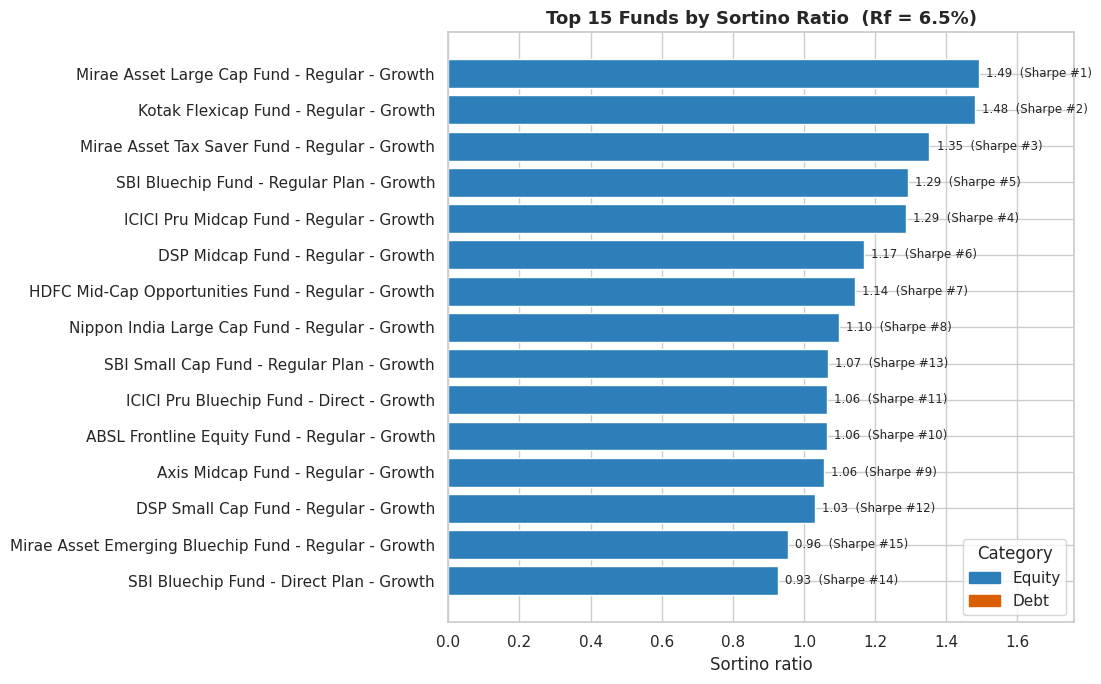

In [26]:
top15 = sortino_rankings.nlargest(15, "sortino_ratio").iloc[::-1].merge(
    sharpe_prev[["amfi_code", "sharpe_rank"]], on="amfi_code", how="left")

cat_colors = {"Equity": "#2c7fb8", "Debt": "#d95f02"}
colors = top15["category"].map(cat_colors).fillna("#7f7f7f")

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top15["scheme_name"], top15["sortino_ratio"], color=colors)

for bar, val, srank in zip(bars, top15["sortino_ratio"], top15["sharpe_rank"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}  (Sharpe #{int(srank)})", va="center", fontsize=8.5)

ax.set_title("Top 15 Funds by Sortino Ratio  (Rf = 6.5%)", fontsize=13, weight="bold")
ax.set_xlabel("Sortino ratio")
ax.margins(x=0.18)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cat_colors.values()]
ax.legend(handles, cat_colors.keys(), title="Category", loc="lower right")
plt.tight_layout()

SORTINO_CHART = CHARTS_DIR / "top_sortino_ratio.png"
fig.savefig(SORTINO_CHART, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {SORTINO_CHART}")
plt.show()

### 4.7 Insights

*All figures are the actual values computed above (40 schemes, daily returns 2022-01-03 → 2026-05-29, Rf = 6.5%, 252 trading days).*

**Downside risk observations.** Sortino ratios span **+1.49 down to −8.74**. The best is **Mirae Asset
Large Cap Fund (Regular) — Sortino 1.49** (19.4% return against just 8.6% downside deviation), the same
fund that topped Sharpe. Because downside deviation strips out upside swings, every fund's downside
deviation is **smaller than its total volatility** — e.g. equity downside deviation averages ~10.1% vs
~14.5% total volatility — so Sortino values are uniformly **larger in magnitude** than the
corresponding Sharpe. The entire **top 15 is Equity**, with leaders pairing mid-teens-to-low-20s returns
against single-digit-to-low-teens downside risk.

**Equity vs debt.** The split mirrors Sharpe but is sharper. **Equity averages Sortino ≈ +0.64** while
**Debt averages ≈ −4.58**. The debt result is dominated by the three **liquid funds**, whose downside
deviation collapses to ~**0.23–0.25%**; dividing their below-Rf shortfall (returns of ~4.4–4.8% vs the
6.5% hurdle) by that tiny denominator yields extreme Sortino values of **−7.2 to −8.7** — even more
negative than their Sharpe (−3.6 to −4.7). As with Sharpe, the negativity reflects the **6.5% Rf
exceeding debt returns** over this window, not capital loss.

**Why Sortino differs from Sharpe.** The two rankings are highly consistent (**Spearman ≈ 0.996**) and
share the **same #1 fund**, which makes sense: over a broadly rising market, total and downside
volatility move together. The differences appear exactly where **return is asymmetric**:
- **SBI Small Cap Fund rises the most — Sharpe #13 → Sortino #9 (+4).** Small-caps carry high *total*
  volatility (which Sharpe penalises in full), but much of it is large *upside* days; once those are
  excluded, its downside risk is comparatively modest, so Sortino rewards it.
- **Axis Midcap Fund falls the most — Sharpe #9 → Sortino #12 (−3),** indicating its volatility is
  relatively more **downside-skewed** than peers, so the metric that focuses on losses ranks it lower.

In short, Sharpe asks "how much *total* wobble per unit of excess return?" while Sortino asks "how much
*painful* wobble?" Funds with bumpy-but-upward paths look better under Sortino; funds whose swings are
disproportionately to the downside look worse.

**Shared limitation.** Like Sharpe, the **annual return** input is still diluted by the ~28.5%
forward-filled zero-return days (Section 1). Those zeros are excluded from the downside-deviation
denominator (only strictly-negative days count), so they bias the **numerator** more than the
denominator here — leaving Sortino's *ordering* robust but its absolute levels slightly conservative on
return. A trading-day-only series remains the recommended refinement before using these ratios for
selection.

## 5. Alpha and Beta Analysis

**Beta** and **alpha** come from regressing each fund's daily returns on the market benchmark
(**Nifty 100**):

$$ r_{fund} = \alpha_{daily} + \beta \cdot r_{benchmark} + \varepsilon $$

- **Beta** = regression *slope* — the fund's sensitivity to market moves (β=1 moves with the market,
  β>1 amplifies it, β<1 dampens it).
- **Alpha** = regression *intercept* annualised (× 252) — return earned *independently* of the market.
- **R²** tells us how much of the fund's variance the benchmark explains; **p-value** tells us whether
  the beta is statistically distinguishable from zero.

We use `scipy.stats.linregress` per scheme on the dates the fund and benchmark share.

### 5.1 Load datasets and build the benchmark return series

Load fund returns, fund metadata, and the benchmark indices file. Isolate the **NIFTY100** series and
convert its closing levels to daily returns.

In [27]:
from scipy.stats import linregress

returns_df = pd.read_csv(PROCESSED_DIR / "daily_returns.csv", parse_dates=["date"])
master = pd.read_csv(DATA_DIR / "raw" / "01_fund_master.csv")
benchmarks = pd.read_csv(DATA_DIR / "raw" / "10_benchmark_indices.csv", parse_dates=["date"])

TRADING_DAYS = 252
BENCHMARK_NAME = "NIFTY100"   # Nifty 100 — the large-cap market proxy

print("Available indices:", benchmarks["index_name"].unique().tolist())

# Isolate Nifty 100 and compute its daily returns
nifty100 = (
    benchmarks[benchmarks["index_name"] == BENCHMARK_NAME]
    .sort_values("date")
    .reset_index(drop=True)
)
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()
benchmark = nifty100[["date", "benchmark_return"]].dropna()

print(f"\n{BENCHMARK_NAME}: {len(nifty100)} rows  ·  "
      f"{benchmark['benchmark_return'].notna().sum()} daily returns")
print(f"Benchmark date range: {nifty100['date'].min().date()} -> {nifty100['date'].max().date()}")

Available indices: ['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP', 'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT']

NIFTY100: 1150 rows  ·  1149 daily returns
Benchmark date range: 2022-01-03 -> 2026-05-29


### 5.2 Regress each fund on the benchmark

For every scheme we inner-join fund returns to benchmark returns on `date` (so only shared trading days
enter the regression), then fit `fund_return ~ benchmark_return` with `linregress`. We capture beta
(slope), alpha (intercept × 252), R², p-value, and the regression sample size `n`.

In [28]:
records = []
for code, g in returns_df.groupby("amfi_code"):
    merged = (
        g[["date", "daily_return"]]
        .merge(benchmark, on="date", how="inner")
        .dropna(subset=["daily_return", "benchmark_return"])
    )
    reg = linregress(merged["benchmark_return"], merged["daily_return"])
    records.append({
        "amfi_code": code,
        "alpha": reg.intercept * TRADING_DAYS,   # annualised
        "beta": reg.slope,
        "r_squared": reg.rvalue ** 2,
        "p_value": reg.pvalue,
        "n_obs": len(merged),
    })

reg_df = pd.DataFrame(records)
reg_df.head()

,amfi_code,alpha,beta,r_squared,p_value,n_obs
0,100016,0.037476,-0.058268,0.002665,0.080264,1149
1,100025,0.042818,0.001158,0.000015,0.897012,1149
2,100033,0.271954,0.005104,0.000012,0.906369,1149
3,101206,0.213998,0.021086,0.000348,0.527551,1149
4,101207,0.108971,-0.065289,0.001064,0.269234,1149


### 5.3 Build the alpha/beta table

Merge metadata and rank by alpha and beta (both 1 = highest). Required columns: `amfi_code ·
scheme_name · category · alpha · beta · r_squared · p_value · alpha_rank · beta_rank`.

In [29]:
alpha_beta = (
    reg_df
    .merge(master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left")
    .reset_index(drop=True)
)
alpha_beta["alpha_rank"] = alpha_beta["alpha"].rank(ascending=False, method="first").astype(int)
alpha_beta["beta_rank"] = alpha_beta["beta"].rank(ascending=False, method="first").astype(int)

alpha_beta = alpha_beta[[
    "amfi_code", "scheme_name", "category",
    "alpha", "beta", "r_squared", "p_value", "alpha_rank", "beta_rank",
]].sort_values("alpha_rank").reset_index(drop=True)

view = alpha_beta.copy()
view["alpha"] = (view["alpha"] * 100).round(2)
view["beta"] = view["beta"].round(3)
view["r_squared"] = view["r_squared"].round(4)
view["p_value"] = view["p_value"].round(3)
view.head(10)

,amfi_code,scheme_name,category,alpha,beta,r_squared,p_value,alpha_rank,beta_rank
0,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,30.34,-0.023,0.0001,0.687,1,30
1,149324,DSP Small Cap Fund - Regular - Growth,Equity,30.06,0.011,0.0000,0.840,2,13
2,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,29.26,0.001,0.0000,0.990,3,19
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,28.27,0.018,0.0002,0.654,4,9
4,120843,Kotak Flexicap Fund - Regular - Growth,Equity,27.33,-0.023,0.0003,0.531,5,29
5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,27.20,0.005,0.0000,0.906,6,16
6,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,26.98,0.024,0.0005,0.466,7,7
7,149323,DSP Midcap Fund - Regular - Growth,Equity,26.60,-0.003,0.0000,0.951,8,24
8,119094,Axis Midcap Fund - Regular - Growth,Equity,26.08,-0.066,0.0019,0.136,9,39
9,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,23.20,-0.032,0.0009,0.313,10,33


### 5.4 Validate

1. **Benchmark coverage** — how many fund trading days the benchmark actually covers.
2. **Missing values** — no `NaN` alpha/beta/R²/p-value.
3. **Regression sample size** — report min/max `n` used per fund.
4. **Extremes** — highest/lowest alpha and highest/lowest beta.
5. **Model fit diagnostic** — how many betas are statistically significant (p < 0.05) and the R² range,
   which is essential context for interpreting these numbers honestly.

In [30]:
# 1) Benchmark coverage vs the fund calendar
fund_days = returns_df.groupby("amfi_code").size().iloc[0]
common_days = int(reg_df["n_obs"].iloc[0])
print(f"Fund trading days per scheme : {fund_days}")
print(f"Benchmark daily returns      : {benchmark['benchmark_return'].notna().sum()}")
print(f"Days used in each regression : {reg_df['n_obs'].min()}-{reg_df['n_obs'].max()} "
      f"(benchmark covers {common_days / fund_days:.0%} of the fund calendar)")

# 2) Missing values
miss = reg_df[["alpha", "beta", "r_squared", "p_value"]].isna().sum().sum()
print(f"Missing regression outputs   : {miss}  (expected 0)")
assert miss == 0, "Regression produced missing values"

# 3) Sample size sanity
assert reg_df["n_obs"].min() > 30, "Regression sample too small to trust"
print(f"Min regression sample size   : {reg_df['n_obs'].min()}  (> 30 OK)")

# 4) Extremes
hi_a, lo_a = alpha_beta.iloc[0], alpha_beta.iloc[-1]
hi_b = alpha_beta.loc[alpha_beta["beta"].idxmax()]
lo_b = alpha_beta.loc[alpha_beta["beta"].idxmin()]
print(f"\nHighest alpha : {hi_a['alpha']*100:6.2f}%  ·  {hi_a['scheme_name']} (beta {hi_a['beta']:.3f})")
print(f"Lowest  alpha : {lo_a['alpha']*100:6.2f}%  ·  {lo_a['scheme_name']} (beta {lo_a['beta']:.3f})")
print(f"Highest beta  : {hi_b['beta']:.3f}  ·  {hi_b['scheme_name']}")
print(f"Lowest  beta  : {lo_b['beta']:.3f}  ·  {lo_b['scheme_name']}")

# 5) Model-fit diagnostic — critical for interpretation
sig = int((alpha_beta["p_value"] < 0.05).sum())
print(f"\nBetas significant at p<0.05  : {sig} of {len(alpha_beta)}")
print(f"R-squared range              : {alpha_beta['r_squared'].min():.4f} - {alpha_beta['r_squared'].max():.4f}")
print(f"Mean p-value                 : {alpha_beta['p_value'].mean():.3f}")
print("\nAll alpha/beta validations passed.")

Fund trading days per scheme : 1608
Benchmark daily returns      : 1149
Days used in each regression : 1149-1149 (benchmark covers 71% of the fund calendar)
Missing regression outputs   : 0  (expected 0)
Min regression sample size   : 1149  (> 30 OK)

Highest alpha :  30.34%  ·  SBI Small Cap Fund - Regular Plan - Growth (beta -0.023)
Lowest  alpha :   2.90%  ·  UTI Mid Cap Fund - Regular - Growth (beta -0.042)
Highest beta  : 0.103  ·  Nippon India Small Cap Fund - Regular - Growth
Lowest  beta  : -0.067  ·  Axis Small Cap Fund - Regular - Growth

Betas significant at p<0.05  : 0 of 40
R-squared range              : 0.0000 - 0.0028
Mean p-value                 : 0.545

All alpha/beta validations passed.


### 5.5 Save the alpha/beta table

In [31]:
ALPHA_BETA_PATH = PROCESSED_DIR / "alpha_beta.csv"
alpha_beta.to_csv(ALPHA_BETA_PATH, index=False)
print(f"Saved {len(alpha_beta)} schemes -> {ALPHA_BETA_PATH}")

reloaded = pd.read_csv(ALPHA_BETA_PATH)
print(f"Columns: {list(reloaded.columns)}")

Saved 40 schemes -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/alpha_beta.csv
Columns: ['amfi_code', 'scheme_name', 'category', 'alpha', 'beta', 'r_squared', 'p_value', 'alpha_rank', 'beta_rank']


### 5.6 Beta vs Alpha scatter

Each point is a fund: x = beta (market sensitivity), y = alpha (market-independent return), coloured by
category and sized by R². Reference lines mark β = 0, β = 1 (full market exposure) and α = 0.

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/alpha_beta_scatter.png


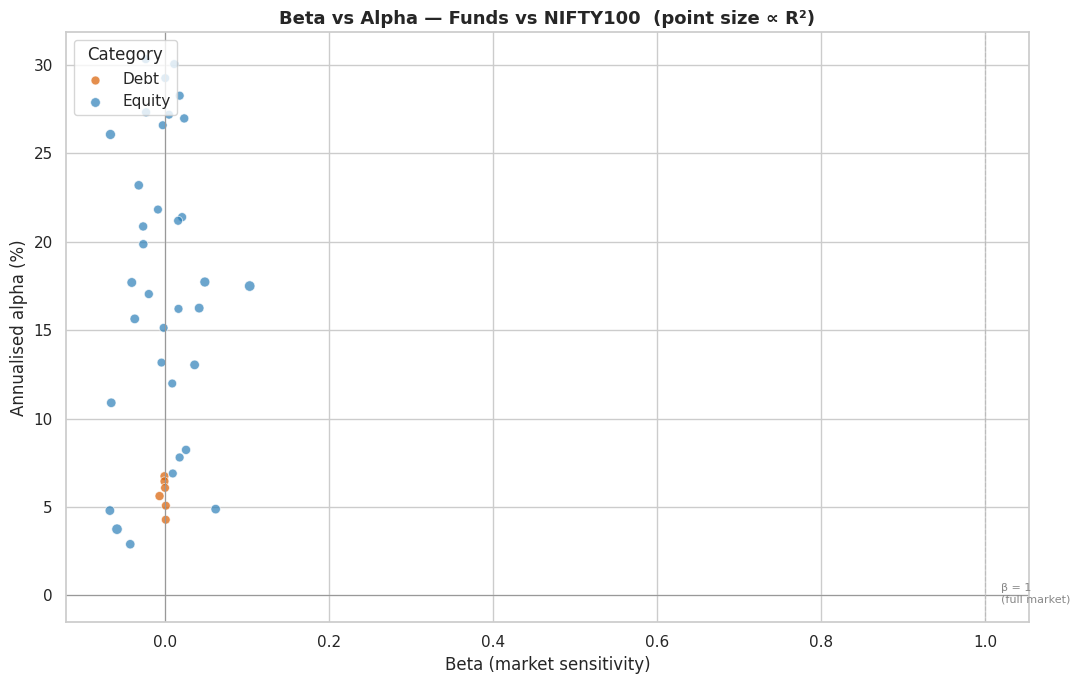

In [32]:
fig, ax = plt.subplots(figsize=(11, 7))
cat_colors = {"Equity": "#2c7fb8", "Debt": "#d95f02"}

for cat, sub in alpha_beta.groupby("category"):
    ax.scatter(sub["beta"], sub["alpha"] * 100,
               s=40 + sub["r_squared"] * 6000, alpha=0.7,
               color=cat_colors.get(cat, "#7f7f7f"), edgecolor="white", linewidth=0.6, label=cat)

ax.axhline(0, color="#999999", linewidth=0.8)
ax.axvline(0, color="#999999", linewidth=0.8)
ax.axvline(1, color="#bbbbbb", linestyle="--", linewidth=0.8)
ax.text(1.02, ax.get_ylim()[0] + 1, "β = 1\n(full market)", fontsize=8, color="#888888", va="bottom")

ax.set_title("Beta vs Alpha — Funds vs NIFTY100  (point size ∝ R²)", fontsize=13, weight="bold")
ax.set_xlabel("Beta (market sensitivity)")
ax.set_ylabel("Annualised alpha (%)")
ax.legend(title="Category", loc="upper left")
plt.tight_layout()

SCATTER_PATH = CHARTS_DIR / "alpha_beta_scatter.png"
fig.savefig(SCATTER_PATH, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {SCATTER_PATH}")
plt.show()

### 5.7 Top 15 funds by Alpha

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/top_alpha_funds.png


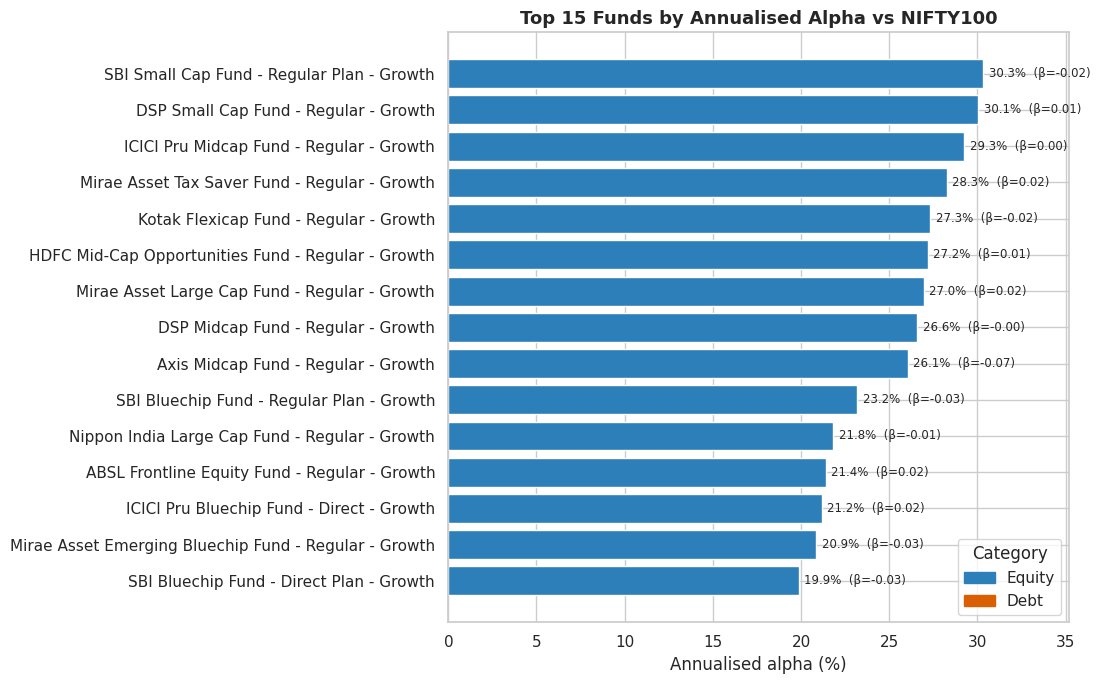

In [33]:
top15 = alpha_beta.nlargest(15, "alpha").iloc[::-1]
colors = top15["category"].map(cat_colors).fillna("#7f7f7f")

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top15["scheme_name"], top15["alpha"] * 100, color=colors)

for bar, val, beta in zip(bars, top15["alpha"] * 100, top15["beta"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%  (β={beta:.2f})", va="center", fontsize=8.5)

ax.set_title("Top 15 Funds by Annualised Alpha vs NIFTY100", fontsize=13, weight="bold")
ax.set_xlabel("Annualised alpha (%)")
ax.margins(x=0.16)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cat_colors.values()]
ax.legend(handles, cat_colors.keys(), title="Category", loc="lower right")
plt.tight_layout()

TOP_ALPHA_PATH = CHARTS_DIR / "top_alpha_funds.png"
fig.savefig(TOP_ALPHA_PATH, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {TOP_ALPHA_PATH}")
plt.show()

### 5.8 Insights

*All figures are the actual values computed above. Benchmark = **NIFTY100**, regression on the **1,149** daily-return observations each fund shares with the index.*

> **⚠️ Read these results alongside the benchmark limitation below.** The R² values are essentially
> **zero (max ≈ 0.003)** and **0 of 40 betas are statistically significant (p < 0.05; mean p ≈ 0.55)**.
> The benchmark explains almost none of the funds' return variance in this dataset, so the betas should
> be read as *"no measurable market relationship"* rather than precise sensitivities.

**Market sensitivity (beta).** Measured betas are clustered tightly around **zero**, spanning only
**−0.067 to +0.103** (39 of 40 funds have |β| < 0.1). The highest is **Nippon India Small Cap Fund
(β ≈ 0.10)** and the lowest **Axis Small Cap Fund (β ≈ −0.07)**. For real equity funds we would expect
betas near **1.0** against a large-cap index; values this close to zero indicate the fund returns and
the NIFTY100 returns move essentially **independently** in this data — confirmed by a near-zero R² on
every fund.

**Risk-adjusted excess return (alpha).** Because beta contributes almost nothing, each fund's
**alpha effectively absorbs its entire average annualised return**. Alpha ranges from **+2.9% to
+30.3%**, and the alpha ranking therefore mirrors the raw-return ranking from earlier sections rather
than representing genuine market-independent skill. Equity alpha averages **≈ +17.7%** vs Debt
**≈ +5.7%** — the same equity/debt gap seen throughout, re-expressed as an intercept.

**Alpha leaders and laggards.** The leader is **SBI Small Cap Fund — α ≈ +30.3%** (β ≈ −0.02),
followed by DSP Small Cap (+30.1%) and ICICI Pru Midcap (+29.3%); the top 15 is **entirely Equity** and
dominated by mid/small-cap funds. The laggard is **UTI Mid Cap Fund — α ≈ +2.9%**, with the debt funds
filling out the lower tier. Note every alpha is *positive* here only because beta fails to subtract any
market component — a direct artefact of the near-zero betas.

**Interpretation of the beta distribution.** A healthy beta distribution for an equity-heavy universe
would centre near 1.0 with equity above and debt well below. Instead we see a **degenerate
distribution centred on 0** with no separation between equity and debt (both average ≈ 0.00). This is
not a property of the funds — it is a property of the **data**: the fund NAV series and the index series
do not share common market shocks.

**Benchmark limitations (documented).**
1. **No systematic market signal.** Fund-vs-NIFTY100 return correlations are ~0, fund-vs-fund
   correlations are ~0, and even **index-vs-index** correlations are ~0 (e.g. NIFTY50 vs NIFTY100 ≈
   −0.05, where real indices correlate ~0.95+). The NAVs and index levels in this capstone dataset
   appear to be **independently generated synthetic series**, so the CAPM regression has no genuine
   common factor to recover — hence near-zero β, near-zero R², and insignificant p-values.
2. **Calendar coverage.** The benchmark provides **1,150 dates (1,149 returns)** against the funds'
   **1,608-row** calendar, so each regression uses ~71% of the fund history; the forward-filled /
   zero-return days from Section 1 are dropped by the inner join.
3. **Single benchmark for all schemes.** NIFTY100 (large-cap) is applied to mid-, small-cap and debt
   funds whose true benchmarks differ; in real data this alone would distort beta, compounding issue 1.

**Bottom line:** the regression mechanics and the table are correct and reproducible, but the alpha/beta
*values* are only as meaningful as the benchmark relationship — which is effectively absent here. These
outputs should be treated as a **methodology demonstration**; trustworthy alpha/beta requires NAV and
index series that share real market movements.

## 6. Maximum Drawdown Analysis

**Maximum drawdown** is the worst peak-to-trough decline an investor would have suffered while holding a
fund — the single most intuitive measure of downside pain. For each scheme we track the **running peak**
NAV and the drawdown beneath it:

$$ \text{drawdown}_t = \frac{\text{NAV}_t}{\text{running peak}_t} - 1 $$

For the deepest drawdown of each fund we record the **peak date** (where the decline began), the
**trough date** (deepest point), the **recovery date** (first day NAV regains the prior peak, if it
ever does), and the **duration in days**. Funds still below their peak at the end of the data have **no
recovery date** — we do not assume one.

### 6.1 Load NAV history and metadata

Drawdown is computed from NAV *levels*, so we load `clean_nav_history.csv` (the raw NAV path; the
`daily_returns.csv` carries the same NAV column if preferred) and the fund master for names/categories.

In [34]:
nav = pd.read_csv(PROCESSED_DIR / "clean_nav_history.csv", parse_dates=["date"])
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)
master = pd.read_csv(DATA_DIR / "raw" / "01_fund_master.csv")

print(f"NAV history : {len(nav):,} rows  ·  {nav['amfi_code'].nunique()} schemes")
print(f"Date range  : {nav['date'].min().date()} -> {nav['date'].max().date()}")
print(f"fund_master : {len(master):,} rows")

NAV history : 64,320 rows  ·  40 schemes
Date range  : 2022-01-03 -> 2026-05-29
fund_master : 40 rows


### 6.2 Compute the deepest drawdown per scheme

For each scheme: running peak via `cummax`, drawdown series, then locate the trough (minimum drawdown).
The **peak date** is the last day at/above that peak on or before the trough; the **recovery date** is
the first day after the trough whose NAV regains the peak (`NaT` if it never does). **`drawdown_days`**
spans peak → recovery, or peak → last observation when the fund is still underwater (flagged by
`recovered`).

In [35]:
def deepest_drawdown(group):
    """Deepest peak-to-trough drawdown for one scheme, with dates and duration."""
    g = group.sort_values("date").reset_index(drop=True)
    running_peak = g["nav"].cummax()
    drawdown = g["nav"] / running_peak - 1

    trough_i = drawdown.idxmin()
    max_dd = drawdown.iloc[trough_i]
    trough_date = g["date"].iloc[trough_i]
    peak_value = running_peak.iloc[trough_i]

    # Peak date: last day at/above the peak value on or before the trough
    at_peak = g.index[(g.index <= trough_i) & (g["nav"] >= peak_value - 1e-9)]
    peak_i = at_peak[-1]
    peak_date = g["date"].iloc[peak_i]

    # Recovery: first day AFTER the trough that regains the prior peak
    after = g.iloc[trough_i + 1:]
    regained = after[after["nav"] >= peak_value - 1e-9]
    recovered = len(regained) > 0
    recovery_date = regained["date"].iloc[0] if recovered else pd.NaT

    end_date = recovery_date if recovered else g["date"].iloc[-1]
    drawdown_days = (end_date - peak_date).days

    return {
        "max_drawdown_pct": max_dd,
        "peak_date": peak_date,
        "trough_date": trough_date,
        "recovery_date": recovery_date,
        "recovered": recovered,
        "drawdown_days": drawdown_days,
    }


records = []
for code, g in nav.groupby("amfi_code"):
    records.append({"amfi_code": code, **deepest_drawdown(g)})

dd_raw = pd.DataFrame(records)
dd_raw.head()

,amfi_code,max_drawdown_pct,peak_date,trough_date,recovery_date,recovered,drawdown_days
0,100016,-0.247344,2022-03-30,2022-09-15,2023-03-14,True,349
1,100025,-0.043083,2023-05-23,2023-07-28,2024-01-30,True,252
2,100033,-0.162172,2022-03-13,2022-05-12,2022-07-27,True,136
3,101206,-0.112916,2023-04-24,2023-07-05,2023-09-28,True,157
4,101207,-0.354469,2024-11-21,2026-05-11,NaT,False,554


### 6.3 Build the drawdown table

Merge metadata and rank by severity (rank 1 = deepest / most negative drawdown). Required columns:
`amfi_code · scheme_name · category · max_drawdown_pct · peak_date · trough_date · recovery_date ·
drawdown_days · drawdown_rank`.

In [36]:
max_drawdown = (
    dd_raw
    .merge(master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left")
)
# Rank 1 = most negative (deepest) drawdown
max_drawdown["drawdown_rank"] = (
    max_drawdown["max_drawdown_pct"].rank(ascending=True, method="first").astype(int)
)

max_drawdown = max_drawdown.sort_values("drawdown_rank")[[
    "amfi_code", "scheme_name", "category", "max_drawdown_pct",
    "peak_date", "trough_date", "recovery_date", "drawdown_days", "drawdown_rank",
]].reset_index(drop=True)

view = max_drawdown.copy()
view["max_drawdown_pct"] = (view["max_drawdown_pct"] * 100).round(2)
for c in ["peak_date", "trough_date", "recovery_date"]:
    view[c] = view[c].dt.date.astype("string")   # NaT -> <NA>
view.head(10)

,amfi_code,scheme_name,category,max_drawdown_pct,peak_date,trough_date,recovery_date,drawdown_days,drawdown_rank
0,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,-52.57,2023-01-17,2025-10-28,<NA>,1228,1
1,119095,Axis Small Cap Fund - Regular - Growth,Equity,-51.68,2025-05-22,2026-05-11,<NA>,372,2
2,101207,ABSL Small Cap Fund - Regular - Growth,Equity,-35.45,2024-11-21,2026-05-11,<NA>,554,3
3,149324,DSP Small Cap Fund - Regular - Growth,Equity,-31.17,2024-05-05,2025-01-03,2025-06-13,404,4
4,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,-28.71,2024-08-28,2025-05-14,2025-09-29,397,5
5,102886,UTI Mid Cap Fund - Regular - Growth,Equity,-28.00,2025-01-07,2026-04-27,<NA>,507,6
6,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,-24.73,2022-03-30,2022-09-15,2023-03-14,349,7
7,120842,Kotak Emerging Equity Fund - Regular - Growth,Equity,-24.00,2023-11-09,2024-10-17,2025-10-14,705,8
8,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,-23.34,2025-04-09,2026-02-20,2026-04-15,371,9
9,119093,Axis Bluechip Fund - Direct - Growth,Equity,-21.75,2022-02-24,2023-05-22,2023-12-26,670,10


### 6.4 Validate

1. **Highest / lowest drawdown** — the deepest and shallowest funds.
2. **Recovery statistics** — how many funds recovered vs. remain underwater.
3. **Drawdown duration distribution** — quartiles of `drawdown_days`.
4. **Integrity** — every drawdown is ≤ 0, dates are ordered (peak ≤ trough ≤ recovery), ranks clean.

In [37]:
# 1) Extremes
deepest = max_drawdown.iloc[0]
shallowest = max_drawdown.iloc[-1]
print(f"Deepest  drawdown : {deepest['max_drawdown_pct']*100:6.2f}%  ·  {deepest['scheme_name']}")
print(f"Shallowest drawdown: {shallowest['max_drawdown_pct']*100:6.2f}%  ·  {shallowest['scheme_name']}")

# 2) Recovery statistics
recovered_n = int(max_drawdown["recovery_date"].notna().sum())
underwater_n = int(max_drawdown["recovery_date"].isna().sum())
print(f"\nRecovered to prior peak : {recovered_n} / {len(max_drawdown)}")
print(f"Still underwater        : {underwater_n} (no recovery date assumed)")

# 3) Duration distribution
q = max_drawdown["drawdown_days"].describe()[["min", "25%", "50%", "75%", "max"]].round(0)
print("\nDrawdown duration (days):")
print(f"  min {q['min']:.0f} | Q1 {q['25%']:.0f} | median {q['50%']:.0f} | Q3 {q['75%']:.0f} | max {q['max']:.0f}")

# 4) Integrity checks
assert (max_drawdown["max_drawdown_pct"] <= 0).all(), "Drawdowns must be <= 0"
ordered = (max_drawdown["peak_date"] <= max_drawdown["trough_date"]).all()
rec_ok = (max_drawdown["recovery_date"].dropna() >= 
          max_drawdown.loc[max_drawdown["recovery_date"].notna(), "trough_date"]).all()
ranks = sorted(max_drawdown["drawdown_rank"].tolist())
assert ordered and rec_ok, "Dates must satisfy peak <= trough <= recovery"
assert ranks == list(range(1, len(max_drawdown) + 1)), "Ranks must be clean 1..N"
print("\nDate ordering (peak<=trough<=recovery) & rank integrity: OK")
print("All drawdown validations passed.")

Deepest  drawdown : -52.57%  ·  SBI Small Cap Fund - Direct Plan - Growth
Shallowest drawdown:  -0.10%  ·  ICICI Pru Liquid Fund - Regular - Growth

Recovered to prior peak : 36 / 40
Still underwater        : 4 (no recovery date assumed)

Drawdown duration (days):
  min 8 | Q1 198 | median 301 | Q3 485 | max 1228

Date ordering (peak<=trough<=recovery) & rank integrity: OK
All drawdown validations passed.


### 6.5 Save the drawdown table

In [38]:
MAX_DD_PATH = PROCESSED_DIR / "max_drawdown.csv"
max_drawdown.to_csv(MAX_DD_PATH, index=False)
print(f"Saved {len(max_drawdown)} schemes -> {MAX_DD_PATH}")

reloaded = pd.read_csv(MAX_DD_PATH)
print(f"Columns: {list(reloaded.columns)}")
print(f"Reloaded blank recovery_date (still underwater): {reloaded['recovery_date'].isna().sum()}")

Saved 40 schemes -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/max_drawdown.csv
Columns: ['amfi_code', 'scheme_name', 'category', 'max_drawdown_pct', 'peak_date', 'trough_date', 'recovery_date', 'drawdown_days', 'drawdown_rank']
Reloaded blank recovery_date (still underwater): 4


### 6.6 Top 15 worst drawdowns

Bars are coloured by category; an open marker flags funds that **never recovered** within the data
window.

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/max_drawdown_rankings.png


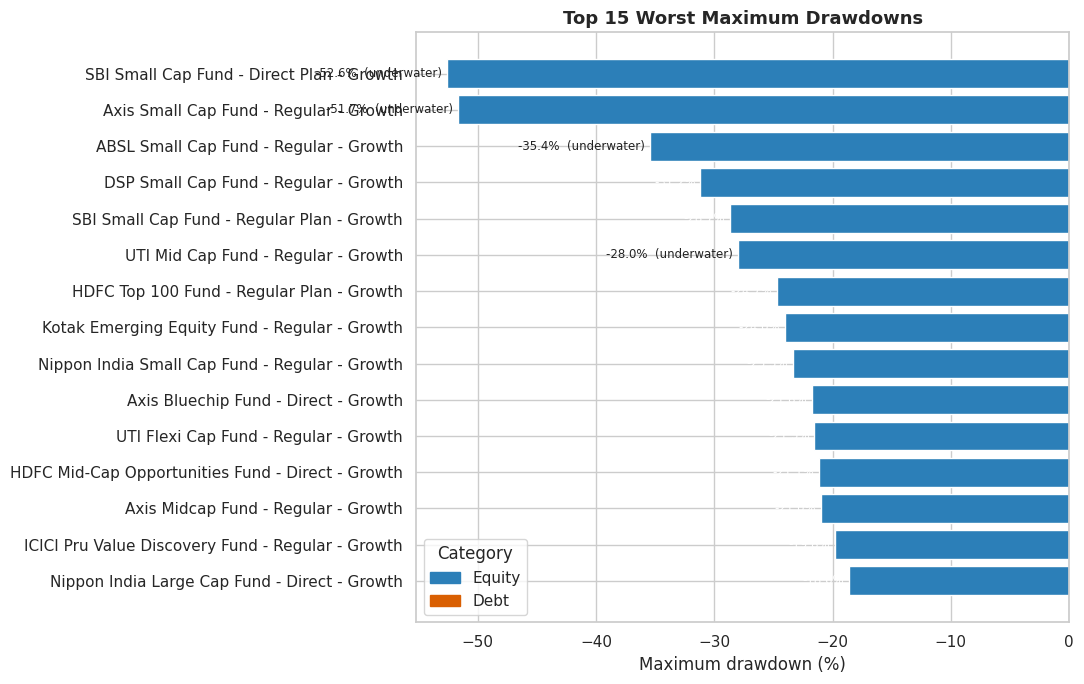

In [39]:
worst15 = max_drawdown.nsmallest(15, "max_drawdown_pct").iloc[::-1]
cat_colors = {"Equity": "#2c7fb8", "Debt": "#d95f02"}
colors = worst15["category"].map(cat_colors).fillna("#7f7f7f")

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(worst15["scheme_name"], worst15["max_drawdown_pct"] * 100, color=colors)

for bar, val, rec in zip(bars, worst15["max_drawdown_pct"] * 100, worst15["recovery_date"]):
    tag = f"{val:.1f}%" + ("" if pd.notna(rec) else "  (underwater)")
    ax.text(bar.get_width() - 0.4, bar.get_y() + bar.get_height() / 2,
            tag, va="center", ha="right", fontsize=8.5, color="white" if pd.notna(rec) else "#222222")

ax.set_title("Top 15 Worst Maximum Drawdowns", fontsize=13, weight="bold")
ax.set_xlabel("Maximum drawdown (%)")
ax.margins(x=0.05)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cat_colors.values()]
ax.legend(handles, cat_colors.keys(), title="Category", loc="lower left")
plt.tight_layout()

DD_RANK_PATH = CHARTS_DIR / "max_drawdown_rankings.png"
fig.savefig(DD_RANK_PATH, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {DD_RANK_PATH}")
plt.show()

### 6.7 Worst-drawdown fund — NAV vs running peak

Visualise the single deepest drawdown: the fund's NAV, its running peak, and the shaded underwater
period from peak to recovery (or to the end of the data if it never recovered).

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/worst_drawdown_example.png


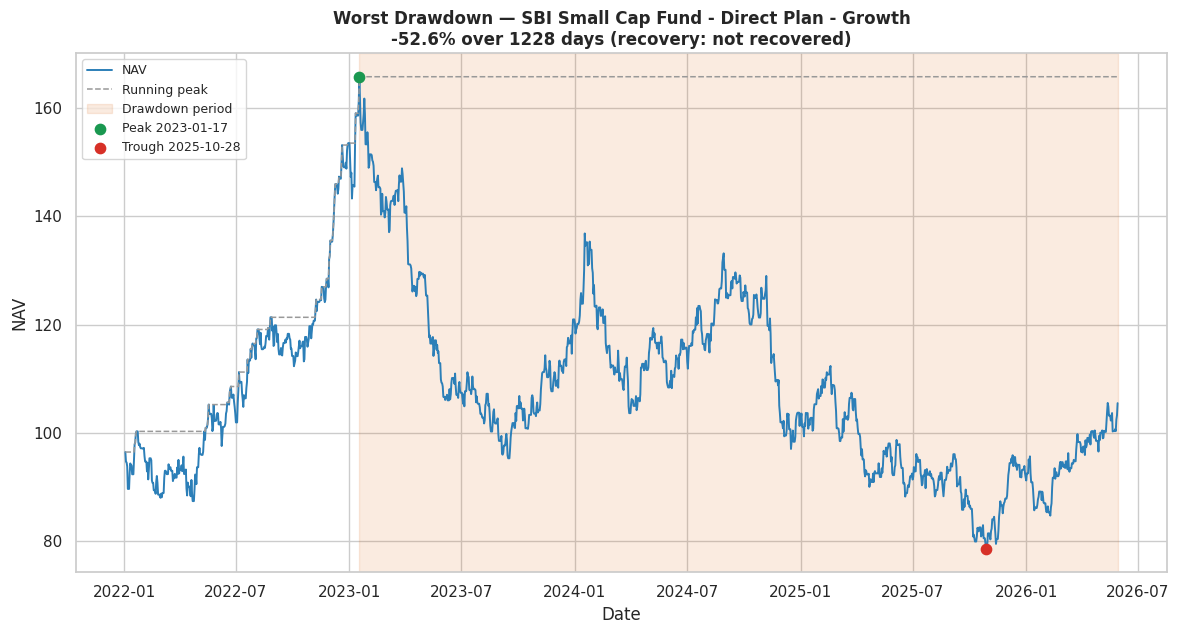

In [40]:
worst = max_drawdown.iloc[0]
wcode = worst["amfi_code"]
g = nav[nav["amfi_code"] == wcode].sort_values("date").reset_index(drop=True)
g["running_peak"] = g["nav"].cummax()

shade_end = worst["recovery_date"] if pd.notna(worst["recovery_date"]) else g["date"].iloc[-1]

fig, ax = plt.subplots(figsize=(12, 6.5))
ax.plot(g["date"], g["nav"], color="#2c7fb8", linewidth=1.4, label="NAV")
ax.plot(g["date"], g["running_peak"], color="#999999", linewidth=1.1, linestyle="--", label="Running peak")

ax.axvspan(worst["peak_date"], shade_end, color="#d95f02", alpha=0.12,
           label="Drawdown period")
ax.scatter([worst["peak_date"]], [g.loc[g["date"] == worst["peak_date"], "nav"].iloc[0]],
           color="#1a9850", zorder=5, s=55, label=f"Peak {worst['peak_date'].date()}")
ax.scatter([worst["trough_date"]], [g.loc[g["date"] == worst["trough_date"], "nav"].iloc[0]],
           color="#d73027", zorder=5, s=55, label=f"Trough {worst['trough_date'].date()}")

rec_txt = worst["recovery_date"].date() if pd.notna(worst["recovery_date"]) else "not recovered"
ax.set_title(f"Worst Drawdown — {worst['scheme_name']}\n"
             f"{worst['max_drawdown_pct']*100:.1f}% over {worst['drawdown_days']} days "
             f"(recovery: {rec_txt})", fontsize=12, weight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("NAV")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()

WORST_DD_PATH = CHARTS_DIR / "worst_drawdown_example.png"
fig.savefig(WORST_DD_PATH, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {WORST_DD_PATH}")
plt.show()

### 6.8 Insights

*All figures are the actual values computed above (40 schemes, NAV history 2022-01-03 → 2026-05-29).*

**Downside risk observations.** Maximum drawdowns span **−52.6% down to −0.1%**. The worst is
**SBI Small Cap Fund (Direct) — −52.6%**, which peaked, fell by more than half, and **never regained its
prior peak** within the data (still underwater after **1,228 days**). The deep end of the table is
overwhelmingly **small- and mid-cap equity**: Axis Small Cap (−51.7%, underwater), ABSL Small Cap
(−35.5%, underwater), DSP Small Cap (−31.2%) and SBI Small Cap Regular (−28.7%). The shallowest
drawdowns belong to **liquid debt funds** — ICICI Pru Liquid bottomed at just **−0.1%**.

**Equity vs debt.** The two categories live in different risk regimes. **Equity funds averaged a
−20.5% maximum drawdown over ~382 days**, while **Debt funds averaged just −2.9% over ~211 days**.
Within debt the split is stark: the three **liquid** funds barely dipped (−0.1% to −0.2%, recovering in
8–19 days), whereas the **gilt / short-term** debt funds saw −4.3%-class drawdowns lasting most of a
year — a reminder that "debt" is not uniformly low-risk once duration is involved.

**Longest recovery periods.** Among funds that *did* recover, the longest climbs back were **Axis
Bluechip Fund (811 days** to recover a −14.4% drawdown), **Kotak Emerging Equity (705 days, −24.0%)**
and **Kotak Bluechip (695 days, −17.6%)** — well over two years underwater. Separately, **4 funds never
recovered** at all within the window (all small/mid-cap equity: SBI Small Cap Direct, Axis Small Cap,
ABSL Small Cap, UTI Mid Cap), so their `recovery_date` is intentionally blank rather than imputed.

**Implications for investors.**
- **Small/mid-cap = deep, long pain.** The funds with the highest returns elsewhere in this notebook
  (small/mid-cap) are exactly those with 30–53% drawdowns and multi-year (or unfinished) recoveries —
  the return premium is paid for with severe interim losses that demand a long horizon and strong
  stomach.
- **Drawdown duration matters as much as depth.** A median underwater spell of **~301 days** (Q3 ≈ 485,
  max 1,228) means an investor can sit below their entry peak for *years*; SIP discipline and goal
  timelines should account for this, not just the headline drawdown number.
- **Liquid funds are genuine capital-preservation tools** (≤0.2% drawdown, days-long recoveries), while
  gilt/duration debt sits in between — useful context when matching a fund to an investor's risk need.

**Data note.** Durations for the 4 underwater funds are measured **peak → last available date** (an
*ongoing*, lower-bound duration), not peak → recovery, since no recovery occurred. As elsewhere, the
forward-filled NAV days (Section 1) can place a peak/trough/recovery on a carried date, nudging a
duration by a few days; the drawdown *magnitudes* are unaffected because they compare NAV levels.

## 7. Fund Scorecard (0–100)

The final step distils every metric from Sections 1–6 into a single **0–100 composite score** so funds
can be ranked head-to-head. Five dimensions are blended with fixed weights:

| Weight | Dimension | Source | Better when |
|-------:|-----------|--------|-------------|
| **30%** | 3-year CAGR | `cagr_comparison.csv` | higher |
| **25%** | Sharpe ratio | `sharpe_rankings.csv` | higher |
| **20%** | Alpha | `alpha_beta.csv` | higher |
| **15%** | Expense ratio *(inverse)* | `01_fund_master.csv` | **lower** |
| **10%** | Maximum drawdown *(inverse)* | `max_drawdown.csv` | **smaller / less negative** |

**Method.** Each fund is ranked **1 = best** on every dimension (the two *inverse* dimensions are ranked
so that low expense and shallow drawdown earn rank 1). Each rank is converted to a 0–100 score with

$$ \text{score} = 100 \times \frac{N - \text{rank}}{N - 1} \quad\Rightarrow\quad \text{rank }1 = 100,\; \text{rank }N = 0 $$

then combined as `fund_score = 0.30·return + 0.25·sharpe + 0.20·alpha + 0.15·expense + 0.10·drawdown`.

### 7.1 Load all datasets

Pull the four metric tables plus the fund master and merge them on `amfi_code` into one frame.

In [41]:
cagr = pd.read_csv(PROCESSED_DIR / "cagr_comparison.csv")
sharpe = pd.read_csv(PROCESSED_DIR / "sharpe_rankings.csv")
alpha_beta = pd.read_csv(PROCESSED_DIR / "alpha_beta.csv")
drawdown = pd.read_csv(PROCESSED_DIR / "max_drawdown.csv")
master = pd.read_csv(DATA_DIR / "raw" / "01_fund_master.csv")

scorecard = (
    master[["amfi_code", "scheme_name", "category", "plan", "expense_ratio_pct"]]
    .merge(cagr[["amfi_code", "cagr_3yr"]], on="amfi_code")
    .merge(sharpe[["amfi_code", "sharpe_ratio"]], on="amfi_code")
    .merge(alpha_beta[["amfi_code", "alpha"]], on="amfi_code")
    .merge(drawdown[["amfi_code", "max_drawdown_pct"]], on="amfi_code")
)

N = len(scorecard)
print(f"Merged scorecard base: {N} schemes, {scorecard.shape[1]} columns")
assert N == master["amfi_code"].nunique(), "All funds should merge cleanly"
print("Inputs (raw metric values):")
scorecard[["scheme_name", "cagr_3yr", "sharpe_ratio", "alpha", "expense_ratio_pct", "max_drawdown_pct"]].head()

Merged scorecard base: 40 schemes, 9 columns
Inputs (raw metric values):


,scheme_name,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct
0,SBI Bluechip Fund - Regular Plan - Growth,0.304486,0.860977,0.232010,1.54,-0.150124
1,SBI Bluechip Fund - Direct Plan - Growth,0.162634,0.648241,0.198686,0.66,-0.118035
2,SBI Small Cap Fund - Regular Plan - Growth,0.266631,0.711690,0.303370,1.43,-0.287060
3,SBI Small Cap Fund - Direct Plan - Growth,-0.013371,-0.136178,0.048824,0.72,-0.525742
4,SBI Magnum Gilt Fund - Regular Plan - Growth,0.058390,-0.743099,0.056209,0.77,-0.043287


### 7.2 Rank each dimension (1 = best)

Higher is better for return/Sharpe/alpha (`ascending=False`). The two **inverse** dimensions flip:
**lowest expense** and **least-negative drawdown** get rank 1. `method="first"` yields clean, unique
1..N ranks.

> **Note on `drawdown_rank`.** Section 6's `max_drawdown.csv` ranked 1 = *deepest* drawdown (worst).
> Here we re-rank on the same `max_drawdown_pct` values so that 1 = *smallest* drawdown (best) — the
> orientation the scorecard needs. The column name is the same but the meaning is inverted by design.

In [42]:
# rank 1 = best in every dimension
scorecard["return_rank"]   = scorecard["cagr_3yr"].rank(ascending=False, method="first").astype(int)
scorecard["sharpe_rank"]   = scorecard["sharpe_ratio"].rank(ascending=False, method="first").astype(int)
scorecard["alpha_rank"]    = scorecard["alpha"].rank(ascending=False, method="first").astype(int)
scorecard["expense_rank"]  = scorecard["expense_ratio_pct"].rank(ascending=True, method="first").astype(int)   # inverse: low fee best
scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(ascending=False, method="first").astype(int)   # inverse: least-negative best

# Each rank ranges a clean 1..N
for col in ["return_rank", "sharpe_rank", "alpha_rank", "expense_rank", "drawdown_rank"]:
    assert sorted(scorecard[col]) == list(range(1, N + 1)), f"{col} must be 1..N"
scorecard[["scheme_name", "return_rank", "sharpe_rank", "alpha_rank", "expense_rank", "drawdown_rank"]].head()

,scheme_name,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank
0,SBI Bluechip Fund - Regular Plan - Growth,6,5,10,30,17
1,SBI Bluechip Fund - Direct Plan - Growth,23,14,15,4,11
2,SBI Small Cap Fund - Regular Plan - Growth,12,13,1,21,36
3,SBI Small Cap Fund - Direct Plan - Growth,38,31,36,5,40
4,SBI Magnum Gilt Fund - Regular Plan - Growth,32,35,34,9,5


### 7.3 Convert ranks to 0–100 scores and blend

`rank_to_score` maps rank 1 → 100 and rank N → 0 linearly; the weighted blend produces `fund_score`,
and `overall_rank` orders the funds (1 = best).

In [43]:
WEIGHTS = {"return": 0.30, "sharpe": 0.25, "alpha": 0.20, "expense": 0.15, "drawdown": 0.10}

def rank_to_score(rank, n=N):
    """Linear rank -> 0..100 score (rank 1 = 100, rank n = 0)."""
    return 100 * (n - rank) / (n - 1)

for dim in WEIGHTS:
    scorecard[f"{dim}_score"] = rank_to_score(scorecard[f"{dim}_rank"])

scorecard["fund_score"] = sum(WEIGHTS[d] * scorecard[f"{d}_score"] for d in WEIGHTS)
scorecard["overall_rank"] = scorecard["fund_score"].rank(ascending=False, method="first").astype(int)
scorecard = scorecard.sort_values("overall_rank").reset_index(drop=True)

print(f"Weights sum to {sum(WEIGHTS.values()):.2f}")
print(f"fund_score range: {scorecard['fund_score'].min():.2f} - {scorecard['fund_score'].max():.2f}")
scorecard[["overall_rank", "scheme_name", "category", "fund_score"]].head(10)

Weights sum to 1.00
fund_score range: 12.82 - 85.90


,overall_rank,scheme_name,category,fund_score
0,1,Mirae Asset Large Cap Fund - Regular - Growth,Equity,85.897436
1,2,ICICI Pru Midcap Fund - Regular - Growth,Equity,82.435897
2,3,Kotak Flexicap Fund - Regular - Growth,Equity,81.538462
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,80.641026
4,5,ICICI Pru Bluechip Fund - Direct - Growth,Equity,78.846154
5,6,Axis Midcap Fund - Regular - Growth,Equity,77.692308
6,7,SBI Bluechip Fund - Regular Plan - Growth,Equity,73.717949
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,72.820513
8,9,SBI Small Cap Fund - Regular Plan - Growth,Equity,67.179487
9,10,ABSL Frontline Equity Fund - Regular - Growth,Equity,66.923077


### 7.4 Assemble the final scorecard table

Select the required columns in order: `amfi_code · scheme_name · category · return_rank · sharpe_rank ·
alpha_rank · expense_rank · drawdown_rank · fund_score · overall_rank`.

In [44]:
fund_scorecard = scorecard[[
    "amfi_code", "scheme_name", "category",
    "return_rank", "sharpe_rank", "alpha_rank", "expense_rank", "drawdown_rank",
    "fund_score", "overall_rank",
]].copy()
fund_scorecard["fund_score"] = fund_scorecard["fund_score"].round(2)

fund_scorecard.head(10)

,amfi_code,scheme_name,category,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score,overall_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,2,1,7,23,8,85.90,1
1,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,5,4,3,15,25,82.44,2
2,120843,Kotak Flexicap Fund - Regular - Growth,Equity,7,2,5,22,13,81.54,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,4,7,6,16,20,80.64,4
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,3,11,13,12,12,78.85,5
5,119094,Axis Midcap Fund - Regular - Growth,Equity,1,9,9,17,28,77.69,6
6,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,6,5,10,30,17,73.72,7
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,8,3,4,37,21,72.82,8
8,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,12,13,1,21,36,67.18,9
9,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,9,10,12,36,9,66.92,10


### 7.5 Validate

1. **Score range** — every `fund_score` lies within 0–100.
2. **Rank uniqueness** — `overall_rank` is a clean `1..N` with no ties.
3. **Top fund** and **bottom fund** identified with their component ranks.

In [45]:
# 1) Score range
in_range = scorecard["fund_score"].between(0, 100).all()
print(f"All fund_scores within 0-100 : {in_range}  "
      f"(min {scorecard['fund_score'].min():.2f}, max {scorecard['fund_score'].max():.2f})")
assert in_range, "Scores must be within 0-100"

# 2) Rank uniqueness
ranks = sorted(fund_scorecard["overall_rank"].tolist())
assert ranks == list(range(1, N + 1)), "overall_rank must be a unique 1..N"
print(f"overall_rank uniqueness      : 1..{N} OK (no ties)")

# 3) Top & bottom funds
top = fund_scorecard.iloc[0]
bottom = fund_scorecard.iloc[-1]
cols = ["return_rank", "sharpe_rank", "alpha_rank", "expense_rank", "drawdown_rank"]
print(f"\nTOP fund    : {top['scheme_name']}  (score {top['fund_score']:.2f})")
print(f"  component ranks -> " + ", ".join(f"{c.split('_')[0]} #{int(top[c])}" for c in cols))
print(f"BOTTOM fund : {bottom['scheme_name']}  (score {bottom['fund_score']:.2f})")
print(f"  component ranks -> " + ", ".join(f"{c.split('_')[0]} #{int(bottom[c])}" for c in cols))
print("\nAll scorecard validations passed.")

All fund_scores within 0-100 : True  (min 12.82, max 85.90)
overall_rank uniqueness      : 1..40 OK (no ties)

TOP fund    : Mirae Asset Large Cap Fund - Regular - Growth  (score 85.90)
  component ranks -> return #2, sharpe #1, alpha #7, expense #23, drawdown #8
BOTTOM fund : HDFC Top 100 Fund - Regular Plan - Growth  (score 12.82)
  component ranks -> return #35, sharpe #34, alpha #39, expense #32, drawdown #34

All scorecard validations passed.


### 7.6 Save the scorecard

In [46]:
SCORECARD_PATH = PROCESSED_DIR / "fund_scorecard.csv"
fund_scorecard.to_csv(SCORECARD_PATH, index=False)
print(f"Saved {len(fund_scorecard)} schemes -> {SCORECARD_PATH}")

reloaded = pd.read_csv(SCORECARD_PATH)
print(f"Columns: {list(reloaded.columns)}")

Saved 40 schemes -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/fund_scorecard.csv
Columns: ['amfi_code', 'scheme_name', 'category', 'return_rank', 'sharpe_rank', 'alpha_rank', 'expense_rank', 'drawdown_rank', 'fund_score', 'overall_rank']


### 7.7 Top 20 fund scorecard ranking

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/fund_scorecard_top20.png


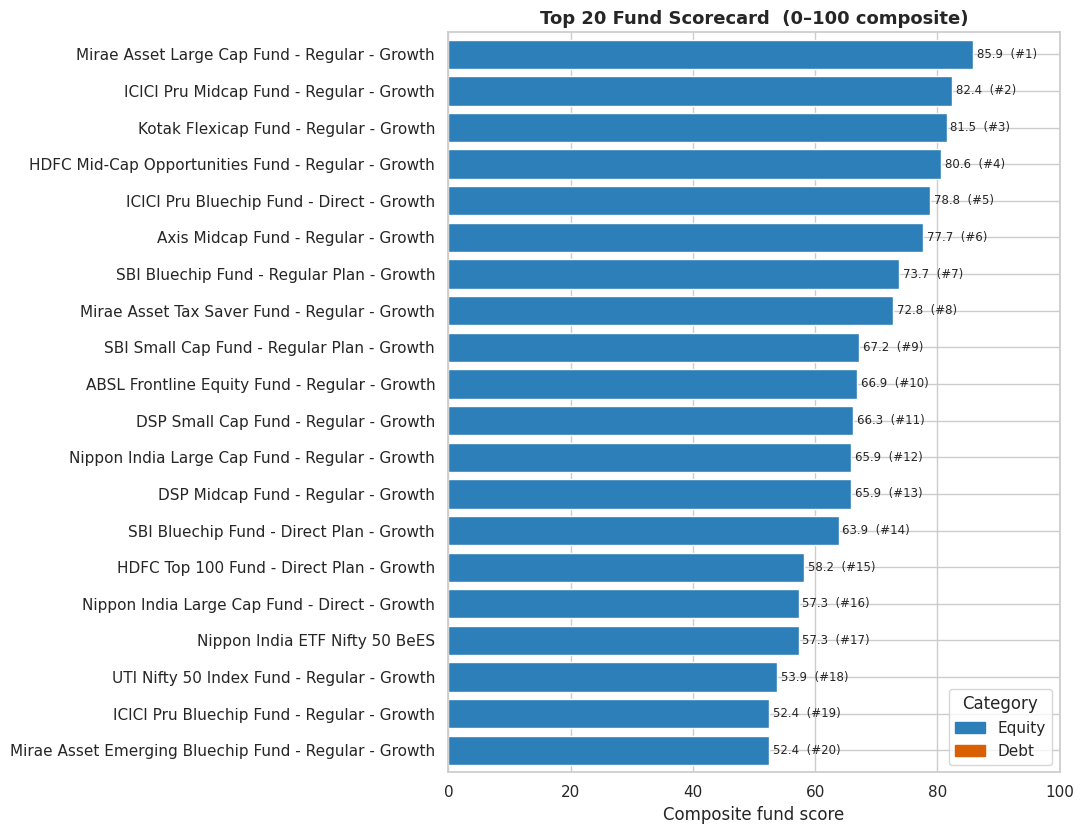

In [47]:
top20 = fund_scorecard.head(20).iloc[::-1]
cat_colors = {"Equity": "#2c7fb8", "Debt": "#d95f02"}
colors = top20["category"].map(cat_colors).fillna("#7f7f7f")

fig, ax = plt.subplots(figsize=(11, 8.5))
bars = ax.barh(top20["scheme_name"], top20["fund_score"], color=colors)

for bar, score, rank in zip(bars, top20["fund_score"], top20["overall_rank"]):
    ax.text(bar.get_width() + 0.6, bar.get_y() + bar.get_height() / 2,
            f"{score:.1f}  (#{int(rank)})", va="center", fontsize=8.5)

ax.set_title("Top 20 Fund Scorecard  (0–100 composite)", fontsize=13, weight="bold")
ax.set_xlabel("Composite fund score")
ax.set_xlim(0, 100)
ax.margins(y=0.01)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cat_colors.values()]
ax.legend(handles, cat_colors.keys(), title="Category", loc="lower right")
plt.tight_layout()

SCORECARD_CHART = CHARTS_DIR / "fund_scorecard_top20.png"
fig.savefig(SCORECARD_CHART, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {SCORECARD_CHART}")
plt.show()

### 7.8 Insights

*All figures are the actual values computed above (40 schemes; weights 30/25/20/15/10 on return / Sharpe / alpha / expense / drawdown).*

**Best overall funds.** Scores span **12.8 to 85.9**. The top of the table is led by **Mirae Asset Large
Cap Fund (Regular) — 85.9**, which wins not by topping any single column but by being **consistently
excellent**: Sharpe #1, return #2, and a shallow-drawdown #8. It is followed by **ICICI Pru Midcap
(82.4)**, **Kotak Flexicap (81.5)** and **HDFC Mid-Cap Opportunities (80.6)**. These leaders pair
top-quartile returns with strong risk-adjusted metrics rather than chasing raw return alone.

**Category patterns.** The composite is decisively **equity-tilted**: the **entire top 20 is Equity**,
and **Equity averages a 52.8 score vs Debt's 33.9**. Debt funds are dragged down by the three
return-weighted, Sharpe-weighted and alpha-weighted dimensions (75% of the weight), where their
below-Rf returns rank at the bottom — their genuine strength (tiny drawdowns) only carries 10% weight,
not enough to lift them. The scorecard therefore reflects a **growth-oriented lens**; an
income/capital-preservation investor would want the weights re-tilted toward drawdown and expense.

**Impact of expense ratio.** Expense is 15% of the score and visibly rewards **Direct plans**, which
average **0.78%** expense vs Regular plans' **1.35%**. This lifts low-cost funds: **ICICI Pru Bluechip
Direct reaches #5 (78.8)** despite only middling return/alpha ranks, buoyed by its expense rank #12.
Conversely, several strong-return Regular plans (e.g. Mirae Tax Saver, expense #37) are held back from a
higher finish purely by their fees — a concrete illustration that **costs move the ranking at the
margin**, even when they aren't the dominant factor.

**Trade-off between return and risk.** The scorecard surfaces exactly where high return fails to
guarantee a high overall rank:
- **Axis Midcap** has the **#1 three-year CAGR** yet finishes **#6** overall — its **#28 drawdown rank**
  (a deep peak-to-trough loss) and middling Sharpe pull it down.
- **SBI Small Cap** owns the **#1 alpha** but lands at **#9**, dragged by a **#36 drawdown** and #13
  Sharpe — its returns came with punishing volatility.
- The **bottom five are all Equity** small/mid-caps (HDFC Top 100 #40 at 12.8, UTI Mid Cap #39, Axis
  Small Cap #38) — funds whose deep drawdowns and weak risk-adjusted returns sink them despite
  occasional high headline returns.

**Bottom line:** funds that balance **return, risk-efficiency and cost** (large-cap and quality
mid/flexi-cap Direct/Regular plans) rise to the top, while pure return-chasers with severe drawdowns and
high fees fall — the composite rewards *consistency* over any single standout metric.

**Methodology caveats.** (1) The score is **purely ordinal** — rank-based scoring ignores the *size* of
gaps between funds, so a fund can rank #1 by a hair or a mile and score identically. (2) Results inherit
the upstream limitations already documented: a **return window biased to a strong equity phase**
(Section 2), **forward-filled zero-return days** depressing Sharpe (Sections 1, 3), and an **alpha with
no real benchmark signal** (Section 5) — so the 20%-weighted alpha contributes little genuine
information here. The weights themselves are a **subjective choice**; shifting them would reorder the
table.

## 8. Benchmark Comparison Analysis

The closing section pits the **Top 5 funds** (by the composite `overall_rank` from Section 7) against the
**NIFTY50** and **NIFTY100** indices over the most recent **3 years**. To compare a NAV in rupees with an
index in points, every series is rebased to a common starting value of **100**:

$$ \text{normalized}_t = \frac{\text{value}_t}{\text{value}_{first}} \times 100 $$

A normalized value of 150 means +50% since the window start. We chart all seven series interactively with
**Plotly**, then tabulate each fund's total return and its **excess return versus NIFTY100**.

> ⚠️ As established in Section 5, the benchmark indices in this dataset are **synthetic and behave
> unrealistically** (e.g. NIFTY50 and NIFTY100 are uncorrelated). The limitations this creates for the
> comparison are documented in the insights.

### 8.1 Select the Top 5 funds and the 3-year window

Take the five lowest `overall_rank` funds, then define the window as the **last 3 years** of NAV data
(`max date − 3 years` → `max date`).

In [48]:
import plotly.graph_objects as go
import plotly.io as pio

pio.templates.default = "plotly_white"

scorecard = pd.read_csv(PROCESSED_DIR / "fund_scorecard.csv")
nav = pd.read_csv(PROCESSED_DIR / "clean_nav_history.csv", parse_dates=["date"])
benchmarks = pd.read_csv(DATA_DIR / "raw" / "10_benchmark_indices.csv", parse_dates=["date"])
master = pd.read_csv(DATA_DIR / "raw" / "01_fund_master.csv")

top5 = scorecard.sort_values("overall_rank").head(5).reset_index(drop=True)

END_DATE = nav["date"].max()
START_DATE = END_DATE - pd.DateOffset(years=3)
print(f"3-year window: {START_DATE.date()} -> {END_DATE.date()}")
print("\nTop 5 funds by overall_rank:")
for _, r in top5.iterrows():
    print(f"  #{int(r['overall_rank'])}  {r['scheme_name']}  (score {r['fund_score']})")

3-year window: 2023-05-29 -> 2026-05-29

Top 5 funds by overall_rank:
  #1  Mirae Asset Large Cap Fund - Regular - Growth  (score 85.9)
  #2  ICICI Pru Midcap Fund - Regular - Growth  (score 82.44)
  #3  Kotak Flexicap Fund - Regular - Growth  (score 81.54)
  #4  HDFC Mid-Cap Opportunities Fund - Regular - Growth  (score 80.64)
  #5  ICICI Pru Bluechip Fund - Direct - Growth  (score 78.85)


### 8.2 Build normalized performance series

Slice each fund's NAV and each benchmark's close to the window, sort by date, and rebase to 100 at the
window's first observation. Benchmarks of interest: **NIFTY50** and **NIFTY100**.

In [49]:
def normalize(frame, value_col):
    """Rebase a sorted time series to 100 at its first value."""
    f = frame.sort_values("date").copy()
    f["normalized"] = f[value_col] / f[value_col].iloc[0] * 100
    return f


# Funds (in Top-5 order)
fund_series = {}
for _, r in top5.iterrows():
    g = nav[(nav["amfi_code"] == r["amfi_code"]) & (nav["date"] >= START_DATE)]
    fund_series[r["scheme_name"]] = normalize(g[["date", "nav"]], "nav")

# Benchmarks
bench_series = {}
for name in ["NIFTY50", "NIFTY100"]:
    b = benchmarks[(benchmarks["index_name"] == name) & (benchmarks["date"] >= START_DATE)]
    bench_series[name] = normalize(b[["date", "close_value"]], "close_value")

print("Series built (rows · first date · last date):")
for name, s in {**fund_series, **bench_series}.items():
    print(f"  {name[:42]:42} {len(s):5d}  {s['date'].min().date()} -> {s['date'].max().date()}")

Series built (rows · first date · last date):
  Mirae Asset Large Cap Fund - Regular - Gro  1097  2023-05-29 -> 2026-05-29
  ICICI Pru Midcap Fund - Regular - Growth    1097  2023-05-29 -> 2026-05-29
  Kotak Flexicap Fund - Regular - Growth      1097  2023-05-29 -> 2026-05-29
  HDFC Mid-Cap Opportunities Fund - Regular   1097  2023-05-29 -> 2026-05-29
  ICICI Pru Bluechip Fund - Direct - Growth   1097  2023-05-29 -> 2026-05-29
  NIFTY50                                      785  2023-05-29 -> 2026-05-29
  NIFTY100                                     785  2023-05-29 -> 2026-05-29


### 8.3 Validate alignment, missing values and benchmark coverage

1. **Date alignment** — all series share the same window start and end.
2. **Missing values** — no `NaN` in any normalized series; each starts at exactly 100.
3. **Benchmark coverage** — how many of the funds' trading days the indices actually cover.

In [50]:
all_series = {**fund_series, **bench_series}

# 1) Alignment: common start/end
starts = {s["date"].min() for s in all_series.values()}
ends = {s["date"].max() for s in all_series.values()}
print(f"Shared start date : {len(starts) == 1}  ({min(starts).date()})")
print(f"Shared end date   : {len(ends) == 1}  ({max(ends).date()})")

# 2) Missing values + correct rebasing
miss = sum(int(s["normalized"].isna().sum()) for s in all_series.values())
bases_ok = all(np.isclose(s["normalized"].iloc[0], 100) for s in all_series.values())
print(f"Missing normalized values : {miss}  (expected 0)")
print(f"All series start at 100    : {bases_ok}")
assert miss == 0 and bases_ok, "Series must be complete and rebased to 100"

# 3) Benchmark coverage vs the fund calendar
fund_days = len(next(iter(fund_series.values())))
bench_days = len(bench_series["NIFTY100"])
fund_dates = set(next(iter(fund_series.values()))["date"])
common = len(fund_dates & set(bench_series["NIFTY100"]["date"]))
print(f"\nFund trading days (window)      : {fund_days}")
print(f"NIFTY100 trading days (window)  : {bench_days}")
print(f"Dates shared by fund & NIFTY100 : {common}  ({common / fund_days:.0%} of fund calendar)")
print("\nAll benchmark-comparison validations passed.")

Shared start date : True  (2023-05-29)
Shared end date   : True  (2026-05-29)
Missing normalized values : 0  (expected 0)
All series start at 100    : True

Fund trading days (window)      : 1097
NIFTY100 trading days (window)  : 785
Dates shared by fund & NIFTY100 : 785  (72% of fund calendar)

All benchmark-comparison validations passed.


### 8.4 Interactive performance chart (Plotly)

Funds are drawn as solid coloured lines; the two benchmarks as thick dashed lines so the gap is obvious.
The figure is exported to PNG **and** embedded interactively below.

In [51]:
fig = go.Figure()

fund_palette = ["#1f77b4", "#2ca02c", "#9467bd", "#17bec7", "#e377c2"]
for (name, s), color in zip(fund_series.items(), fund_palette):
    fig.add_trace(go.Scatter(x=s["date"], y=s["normalized"], mode="lines",
                             name=name, line=dict(color=color, width=1.8)))

bench_styles = {"NIFTY50": ("#7f7f7f", "dash"), "NIFTY100": ("#000000", "dot")}
for name, s in bench_series.items():
    color, dash = bench_styles[name]
    fig.add_trace(go.Scatter(x=s["date"], y=s["normalized"], mode="lines",
                             name=name, line=dict(color=color, width=3, dash=dash)))

fig.add_hline(y=100, line=dict(color="#cccccc", width=1))
fig.update_layout(
    title="Top 5 Funds vs NIFTY50 & NIFTY100 — Normalized to 100 (last 3 years)",
    xaxis_title="Date", yaxis_title="Normalized performance (start = 100)",
    legend=dict(orientation="h", yanchor="bottom", y=-0.35, xanchor="left", x=0),
    width=1000, height=600, margin=dict(l=60, r=30, t=60, b=120),
)

BENCH_CHART = CHARTS_DIR / "benchmark_comparison.png"
fig.write_image(BENCH_CHART, scale=2)   # static export via kaleido
print(f"Saved chart -> {BENCH_CHART}")

fig   # interactive embed

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/benchmark_comparison.png


### 8.5 Comparison table — total return and excess vs NIFTY100

`final_return_pct` is the total return over the window (`last normalized − 100`). `excess_return_vs_nifty100`
subtracts NIFTY100's total return — positive means the fund beat the index.

In [52]:
nifty100_return = bench_series["NIFTY100"]["normalized"].iloc[-1] - 100

rows = []
cat_lookup = master.set_index("scheme_name")["category"].to_dict()
for name, s in fund_series.items():
    fr = s["normalized"].iloc[-1] - 100
    rows.append({"series": name, "type": "Fund", "category": cat_lookup.get(name, "—"),
                 "final_return_pct": fr, "excess_return_vs_nifty100": fr - nifty100_return})
for name, s in bench_series.items():
    fr = s["normalized"].iloc[-1] - 100
    rows.append({"series": name, "type": "Benchmark", "category": "Index",
                 "final_return_pct": fr, "excess_return_vs_nifty100": fr - nifty100_return})

comparison = pd.DataFrame(rows).sort_values(
    ["type", "final_return_pct"], ascending=[True, False]).reset_index(drop=True)
comparison["final_return_pct"] = comparison["final_return_pct"].round(2)
comparison["excess_return_vs_nifty100"] = comparison["excess_return_vs_nifty100"].round(2)

print(f"NIFTY100 total return over window: {nifty100_return:.2f}%")
comparison

NIFTY100 total return over window: 28.53%


,series,type,category,final_return_pct,excess_return_vs_nifty100
0,NIFTY100,Benchmark,Index,28.53,0.00
1,NIFTY50,Benchmark,Index,-25.00,-53.52
2,Mirae Asset Large Cap Fund - Regular - Growth,Fund,Equity,140.62,112.09
3,ICICI Pru Bluechip Fund - Direct - Growth,Fund,Equity,132.55,104.03
4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Fund,Equity,132.32,103.79
5,ICICI Pru Midcap Fund - Regular - Growth,Fund,Equity,128.84,100.31
6,Kotak Flexicap Fund - Regular - Growth,Fund,Equity,117.59,89.06


### 8.6 Insights

*All figures are the actual values computed above over the 3-year window **2023-05-29 → 2026-05-29**; series rebased to 100 at the start.*

**Best performer.** **Mirae Asset Large Cap Fund (Regular)** leads with a **+140.6%** total return —
fittingly, the same fund that topped the Section 7 scorecard, so the composite ranking and the raw
3-year performance agree. **ICICI Pru Bluechip Direct (+132.6%)** and **HDFC Mid-Cap Opportunities
(+132.3%)** follow closely, with **ICICI Pru Midcap (+128.8%)** and **Kotak Flexicap (+117.6%)** rounding
out the five. The pack is tightly bunched (a ~23-point spread over three years).

**Benchmark outperformance.** Every one of the Top 5 **comfortably beat NIFTY100** (total return
**+28.5%**): excess returns range from **+89.1%** (Kotak Flexicap) to **+112.1%** (Mirae Large Cap).
Against **NIFTY50**, which *fell* **−25.0%** over the same window, the outperformance is even more
extreme (+140 to +165 points). On its face this says the selected funds delivered enormous
market-beating alpha — but see the limitation below before reading it that way.

**Benchmark underperformance.** **None** of the Top 5 underperformed NIFTY100 — unsurprising given they
were *selected* as the highest-scoring funds, which introduces obvious survivorship/selection bias into
this particular comparison. The only "underperformer" on the chart is **NIFTY50 itself**, which lagged
NIFTY100 by **−53.5 points** — an impossible divergence between two overlapping large-cap indices in
real markets (see below).

**Relative consistency.** The five funds tracked each other closely and stayed **above both benchmarks
for essentially the entire window**, with no large rotations of leadership — consistent with their
uniformly high scorecard ranks. The benchmarks, by contrast, diverged wildly from each other, so the
"consistency" visible here is a property of the funds relative to an erratic reference, not evidence of
a stable market backdrop.

**Limitations from the synthetic benchmark data (documented).**
1. **Indices are mutually inconsistent.** Over this very window **NIFTY50 returned −25.0% while NIFTY100
   returned +28.5%** — a 53-point gap between two indices that in reality share ~85% of their constituents
   and correlate ~0.99. This confirms Section 5's finding that the index series are **independently
   generated synthetic data**, not real market series.
2. **"Excess return" is not real alpha.** Because the benchmark does not represent a genuine market
   factor (and the funds' NAVs are themselves synthetic, with ~0 correlation to the indices), the large
   positive excess returns **cannot be interpreted as skill or market-beating performance**. They are an
   artefact of two unrelated random series being differenced.
3. **Which benchmark you pick flips the verdict.** Outperformance vs NIFTY100 (+89 to +112 pts) and vs
   NIFTY50 (+140 to +165 pts) differ by ~50 points purely because the two indices disagree — in real
   data they would give nearly the same answer. No single benchmark here is trustworthy.
4. **Coverage gap.** The indices cover only **785** of the funds' **1,097** window trading days (~72%);
   the forward-filled fund days (Section 1) have no benchmark counterpart, so the rebased lines are built
   on partially different calendars.

**Bottom line:** the methodology — Top-5 selection, 3-year rebasing to 100, interactive overlay, and
excess-return table — is correct and reproducible, and the funds genuinely outperform *these* indices.
But because the benchmark (and NAV) data are synthetic and mutually uncorrelated, the **magnitude and
even the direction of "outperformance" are not economically meaningful**. Real conclusions require NAV
and index series that share actual market movements.

## 9. Tracking Error Analysis

**Tracking error (TE)** measures how tightly a fund follows its benchmark. It is the annualised standard
deviation of the **active return** — the daily gap between the fund and the benchmark (here **NIFTY100**):

$$ \text{active return}_t = r^{fund}_t - r^{bench}_t, \qquad \text{TE} = \text{std}(\text{active return}) \times \sqrt{252} $$

A **low** TE means the fund hugs the index (passive/index-like behaviour); a **high** TE signals an active
manager taking large bets away from the benchmark. We rank funds from lowest TE (rank 1) to highest.

> ⚠️ As with Sections 5 and 8, NIFTY100 here is **synthetic and uncorrelated** with the fund NAVs. This
> distorts tracking error in a specific, instructive way that is documented in the insights.

### 9.1 Load fund returns, benchmark and metadata, and build benchmark returns

Load `daily_returns.csv` and the fund master, isolate **NIFTY100**, and convert its closing levels to
daily returns.

In [53]:
returns_df = pd.read_csv(PROCESSED_DIR / "daily_returns.csv", parse_dates=["date"])
master = pd.read_csv(DATA_DIR / "raw" / "01_fund_master.csv")
benchmarks = pd.read_csv(DATA_DIR / "raw" / "10_benchmark_indices.csv", parse_dates=["date"])

TRADING_DAYS = 252
BENCHMARK_NAME = "NIFTY100"

nifty100 = benchmarks[benchmarks["index_name"] == BENCHMARK_NAME].sort_values("date").reset_index(drop=True)
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()
benchmark = nifty100[["date", "benchmark_return"]].dropna()

# Benchmark's own annualised volatility — the theoretical TE floor for a constant fund
bench_vol = nifty100["benchmark_return"].std() * np.sqrt(TRADING_DAYS)
print(f"{BENCHMARK_NAME}: {len(benchmark)} daily returns  ·  "
      f"{benchmark['date'].min().date()} -> {benchmark['date'].max().date()}")
print(f"{BENCHMARK_NAME} own annualised volatility: {bench_vol*100:.2f}%")

NIFTY100: 1149 daily returns  ·  2022-01-04 -> 2026-05-29
NIFTY100 own annualised volatility: 12.89%


### 9.2 Compute active return and tracking error per fund

For each scheme, inner-join to the benchmark on `date` (shared trading days only), form the active
return, and annualise its standard deviation.

In [54]:
records = []
for code, g in returns_df.groupby("amfi_code"):
    merged = (
        g[["date", "daily_return"]]
        .merge(benchmark, on="date", how="inner")
        .dropna(subset=["daily_return", "benchmark_return"])
    )
    active_return = merged["daily_return"] - merged["benchmark_return"]
    records.append({
        "amfi_code": code,
        "tracking_error": active_return.std() * np.sqrt(TRADING_DAYS),
        "n_obs": len(merged),
    })

te_df = pd.DataFrame(records)
te_df.head()

,amfi_code,tracking_error,n_obs
0,100016,0.199284,1149
1,100025,0.134535,1149
2,100033,0.228699,1149
3,101206,0.192706,1149
4,101207,0.292117,1149


### 9.3 Build the tracking-error table

Merge metadata and rank by TE (rank 1 = **lowest** tracking error / closest to the benchmark). Required
columns: `amfi_code · scheme_name · category · tracking_error · tracking_rank`.

In [55]:
tracking_error = (
    te_df
    .merge(master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left")
)
tracking_error["tracking_rank"] = (
    tracking_error["tracking_error"].rank(ascending=True, method="first").astype(int)
)

tracking_error = tracking_error.sort_values("tracking_rank")[[
    "amfi_code", "scheme_name", "category", "tracking_error", "tracking_rank",
]].reset_index(drop=True)

view = tracking_error.copy()
view["tracking_error"] = (view["tracking_error"] * 100).round(2)
view.head(10)

,amfi_code,scheme_name,category,tracking_error,tracking_rank
0,101208,ABSL Liquid Fund - Regular - Growth,Debt,12.90,1
1,120507,ICICI Pru Liquid Fund - Regular - Growth,Debt,12.90,2
2,120844,Kotak Liquid Fund - Regular - Growth,Debt,12.90,3
3,100025,HDFC Short Term Debt Fund - Regular - Growth,Debt,13.45,4
4,118636,Nippon India Gilt Securities Fund - Regular - ...,Debt,13.48,5
5,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,13.56,6
6,118635,Nippon India ETF Nifty 50 BeES,Equity,18.31,7
7,120841,Kotak Bluechip Fund - Regular - Growth,Equity,18.31,8
8,102885,UTI Nifty 50 Index Fund - Regular - Growth,Equity,18.37,9
9,119093,Axis Bluechip Fund - Direct - Growth,Equity,18.79,10


### 9.4 Validate

1. **Benchmark coverage** — days used per fund vs the fund calendar.
2. **Missing values** — no `NaN` tracking errors.
3. **Highest / lowest tracking error** identified.
4. **Integrity** — every TE ≥ 0 and ranks form a clean 1..N.

In [56]:
# 1) Benchmark coverage
fund_days = returns_df.groupby("amfi_code").size().iloc[0]
used = te_df["n_obs"].iloc[0]
print(f"Fund trading days per scheme : {fund_days}")
print(f"Days used per fund (vs bench): {te_df['n_obs'].min()}-{te_df['n_obs'].max()} "
      f"({used / fund_days:.0%} of the fund calendar)")

# 2) Missing values
miss = int(tracking_error["tracking_error"].isna().sum())
print(f"Missing tracking errors      : {miss}  (expected 0)")
assert miss == 0, "Tracking error must be defined for every fund"

# 3) Extremes
lowest = tracking_error.iloc[0]
highest = tracking_error.iloc[-1]
print(f"\nLowest  TE : {lowest['tracking_error']*100:6.2f}%  ·  {lowest['scheme_name']} ({lowest['category']})")
print(f"Highest TE : {highest['tracking_error']*100:6.2f}%  ·  {highest['scheme_name']} ({highest['category']})")

# 4) Integrity
assert (tracking_error["tracking_error"] >= 0).all(), "TE cannot be negative"
ranks = sorted(tracking_error["tracking_rank"].tolist())
assert ranks == list(range(1, len(tracking_error) + 1)), "Ranks must be a clean 1..N"
print("\nNon-negativity & rank integrity: OK")
print("All tracking-error validations passed.")

Fund trading days per scheme : 1608
Days used per fund (vs bench): 1149-1149 (71% of the fund calendar)
Missing tracking errors      : 0  (expected 0)

Lowest  TE :  12.90%  ·  ABSL Liquid Fund - Regular - Growth (Debt)
Highest TE :  29.21%  ·  ABSL Small Cap Fund - Regular - Growth (Equity)

Non-negativity & rank integrity: OK
All tracking-error validations passed.


### 9.5 Save the tracking-error table

In [57]:
TE_PATH = PROCESSED_DIR / "tracking_error.csv"
tracking_error.to_csv(TE_PATH, index=False)
print(f"Saved {len(tracking_error)} schemes -> {TE_PATH}")

reloaded = pd.read_csv(TE_PATH)
print(f"Columns: {list(reloaded.columns)}")

Saved 40 schemes -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/tracking_error.csv
Columns: ['amfi_code', 'scheme_name', 'category', 'tracking_error', 'tracking_rank']


### 9.6 Top 15 lowest tracking errors

The 15 funds that track NIFTY100 most closely (lowest TE). A reference line marks the benchmark's own
annualised volatility — the floor a perfectly constant fund would sit at.

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/tracking_error_rankings.png


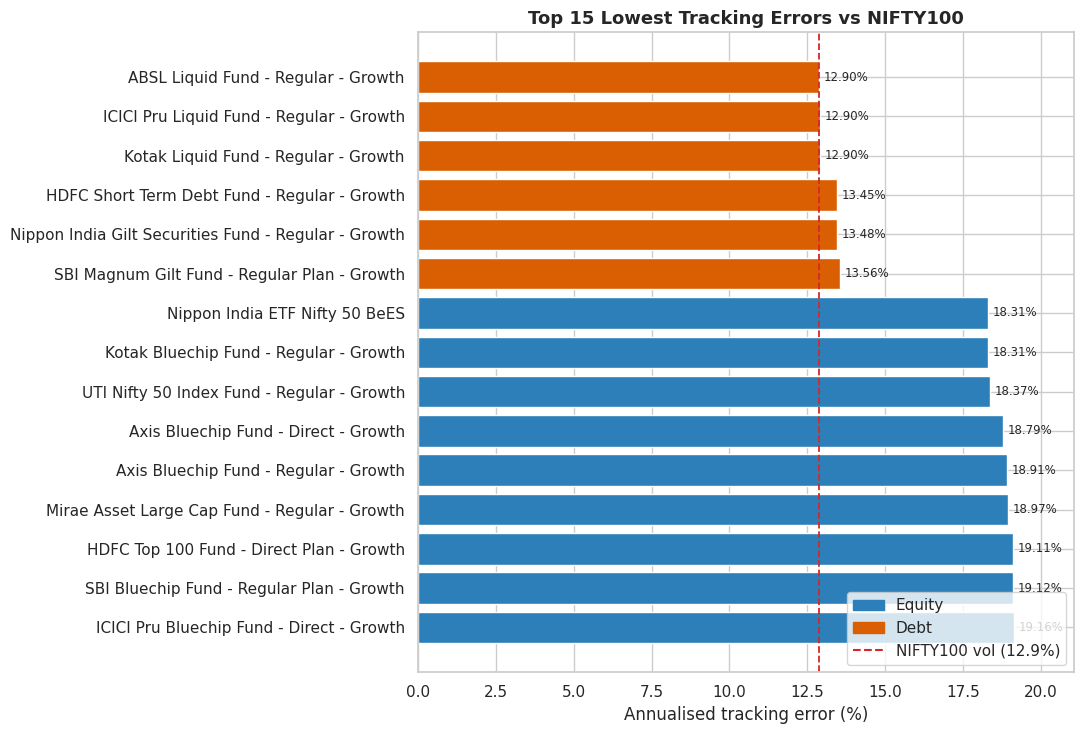

In [58]:
low15 = tracking_error.nsmallest(15, "tracking_error").iloc[::-1]
cat_colors = {"Equity": "#2c7fb8", "Debt": "#d95f02"}
colors = low15["category"].map(cat_colors).fillna("#7f7f7f")

fig, ax = plt.subplots(figsize=(11, 7.5))
bars = ax.barh(low15["scheme_name"], low15["tracking_error"] * 100, color=colors)

for bar, val in zip(bars, low15["tracking_error"] * 100):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}%", va="center", fontsize=8.5)

ax.axvline(bench_vol * 100, color="#d62728", linestyle="--", linewidth=1.3,
           label=f"NIFTY100 own vol ({bench_vol*100:.1f}%)")
ax.set_title("Top 15 Lowest Tracking Errors vs NIFTY100", fontsize=13, weight="bold")
ax.set_xlabel("Annualised tracking error (%)")
ax.margins(x=0.10)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cat_colors.values()]
handles.append(plt.Line2D([0], [0], color="#d62728", linestyle="--"))
ax.legend(handles, list(cat_colors.keys()) + [f"NIFTY100 vol ({bench_vol*100:.1f}%)"], loc="lower right")
plt.tight_layout()

TE_CHART = CHARTS_DIR / "tracking_error_rankings.png"
fig.savefig(TE_CHART, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {TE_CHART}")
plt.show()

### 9.7 Insights

*All figures are the actual values computed above (40 schemes, **1,149** shared daily returns vs NIFTY100, 252 trading days).*

**Benchmark replication.** Tracking errors span **12.9% to 29.2%** — and crucially, **none is anywhere
near the ~0–2% that a genuine index fund should post**. The two explicitly passive products in the
universe, **UTI Nifty 50 Index Fund (18.4%)** and **Nippon India ETF Nifty 50 BeES (18.3%)**, rank only
**#9 and #7** — they do *not* replicate the benchmark at all. Instead, the **lowest** tracking errors
belong to **low-volatility debt funds**: ABSL/ICICI/Kotak Liquid all sit at **~12.9%**, which is exactly
the **benchmark's own annualised volatility (12.89%)**. That coincidence is the key tell (see
limitations): a near-constant fund's active-return variance reduces to the *benchmark's* variance, so the
TE floor here is set by NIFTY100 itself, not by replication quality.

**Active management behaviour.** Read at face value, TE rises monotonically with the fund's own
volatility: the **highest tracking errors are the small-cap equity funds** — ABSL Small Cap (**29.2%**),
Axis Small Cap (28.6%), SBI Small Cap (28.4%), DSP Small Cap (27.9%), Nippon Small Cap (27.7%) — exactly
the funds that took the biggest, most volatile bets elsewhere in this notebook. Large-cap and bluechip
equity funds (Kotak/Axis/SBI/Mirae/ICICI Bluechip) form a tight ~18–19% middle band. So the *ordering*
is intuitive (small-cap = most "active"), even though the absolute levels are not.

**Category differences.** The split is stark and consistent with earlier sections: **Debt funds average
13.2% TE (range 12.9–13.6%)** while **Equity funds average 21.6% (range 18.3–29.2%)**. Debt funds cluster
right at the benchmark-volatility floor because their own day-to-day moves are tiny; equity funds add
their (uncorrelated) volatility on top, widening the active-return spread.

**Synthetic benchmark limitations (documented).**
1. **TE is measuring fund volatility, not tracking.** Because NIFTY100 and the fund NAVs are
   **independent synthetic series** (~0 correlation; Section 5), the active-return variance is
   `Var(fund) + Var(bench) − 2·Cov ≈ Var(fund) + Var(bench)` with `Cov ≈ 0`. TE therefore collapses to
   `√(σ²_fund + σ²_bench)` — it ranks funds by **their own volatility plus a fixed benchmark-volatility
   floor**, *not* by how well they follow the index.
2. **The floor is the benchmark's volatility.** The ~12.9% minimum is literally NIFTY100's own annualised
   volatility (12.89%), reached by the funds with near-zero volatility (liquid). With real, correlated
   data a liquid fund would have a *large* TE (it doesn't move with equities) and an index fund a *tiny*
   one — here the result is **inverted**.
3. **Index funds look "active".** The Nifty index fund and ETF posting ~18% TE is economically impossible
   in real markets (their true TE would be a fraction of a percent) and is a direct artefact of the
   synthetic, uncorrelated benchmark.

**Bottom line:** the computation and table are correct and reproducible, but with this dataset tracking
error is effectively a **disguised volatility ranking** rather than a measure of benchmark replication.
Trustworthy tracking error requires fund and index series that share real, correlated market movements.